In [1]:
from fairness_metric_utils import *
from penalty_utils import *

# Load Data

In [2]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

## Functions

### Without mapped groups

In [3]:
def compute_fairness_metrics_after(cm_dict, m):
  fairness_dict={}
  count_group= {}
  for group, cm in cm_dict.items():
    TP, TN, FP, FN, len_group = retrieve_values(cm)
    fairness_metric = 0
    if FP!=0:
      if m=='PPE':
        fairness_metric = (FP)/(TN+FP) #PredictiveEquality or FalsePositiveRate (FPR)
      elif m=='FPR':
        fairness_metric = (FP)/(TP+FP) #FalsDiscoveryRate
      elif m=='FPP':
        fairness_metric= (FP)/len_group #FalsePositiveParity
      elif m=='FPN':
        fairness_metric= (FP)/(FN+FP)
    if FN!=0:
      if m=='FPA':
        fairness_metric= (FN)/(TN+FN) #FORParity
      elif m=='EOP':
        fairness_metric= (FN)/(TP+FN) #EqualOpportunity
      elif m=='FNP':
        fairness_metric= (FN)/len_group #FalseNegativeParity
      elif m=='FNE':
        fairness_metric=(FN)/(FP+FN)
    if FP!=0 and FN!=0:
      if m=='ERR':
        fairness_metric= (FP+FN)/len_group #ErrorRate
    if TP!=0:
      if m=='GFA':
        fairness_metric = (TP+FP)/len_group #Group Fairness
      elif m=='PPA':
        fairness_metric = (TP)/(TP+FP) #Predictive Parity
      elif m=='OAE':
        fairness_metric= (TP+TN)/len_group #OverallAccuracyEquality
    if FP!=0 or FN!=0:
      fairness_dict[group] = fairness_metric
    else:
      print(f"Warning: Group {mapped_group} {group} has only FN. Skipping fairness metrics calculation.")
    count_group[group]= len_group # len_group = TN + FP + FN + TP
  count_group = convert_types(count_group)
  fairness_dict = convert_types(fairness_dict)  # Ensure Python-native types
  # print("After: ", m, fairness_dict)
  return fairness_dict, count_group

### With Mapped Groups

In [4]:
def compute_fairness_metrics_and_counts(cm_dict, m, sensible_attribute, mapping, dataset_path):
  fairness_dict={}
  count_group= {}
  for group, cm in cm_dict.items():
    TP, TN, FP, FN, len_group = retrieve_values(cm)
    fairness_metric = 0
    if FP!=0:
      if m=='PPE':
        fairness_metric = (FP)/(TN+FP) #PredictiveEquality or FalsePositiveRate (FPR)
      elif m=='FPR':
        fairness_metric = (FP)/(TP+FP) #FalsDiscoveryRate
      elif m=='FPP':
        fairness_metric= (FP)/len_group #FalsePositiveParity
      elif m=='FPN':
        fairness_metric= (FP)/(FN+FP)
    if FN!=0:
      if m=='FPA':
        fairness_metric= (FN)/(TN+FN) #FORParity
      elif m=='EOP':
        fairness_metric= (FN)/(TP+FN) #EqualOpportunity
      elif m=='FNP':
        fairness_metric= (FN)/len_group #FalseNegativeParity
      elif m=='FNE':
        fairness_metric=(FN)/(FP+FN)
    if FP!=0 and FN!=0:
      if m=='ERR':
        fairness_metric= (FP+FN)/len_group #ErrorRate
    if TP!=0:
      if m=='GFA':
        fairness_metric = (TP+FP)/len_group #Group Fairness
      elif m=='PPA':
        fairness_metric = (TP)/(TP+FP) #Predictive Parity
      elif m=='OAE':
        fairness_metric= (TP+TN)/len_group #OverallAccuracyEquality
    if FP!=0 or FN!=0:
      fairness_dict[group] = fairness_metric
    else:
      mapped_group = mapping_numbers_into_labels(group, sensible_attribute, mapping, dataset_path)
      print(f"Warning: Group {mapped_group} {group} has only FN. Skipping fairness metrics calculation.")
    count_group[group]= len_group # len_group = TN + FP + FN + TP
  count_group = convert_types(count_group)
  fairness_dict = convert_types(fairness_dict)  # Ensure Python-native types
  print(m, fairness_dict)
  return fairness_dict, count_group

## Classifier and Predictions

## Functions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

X_train, X_val, X_test: features to train, validate, and evaluate the model

y_train, y_val, y_test: corresponding labels

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, weights
2. Model 2: Fit on training (with weights) → Predict on test (unseen)

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

In [5]:
def compute_predictions(df, target_variable, sensible_attribute, target, target_variable_labels=['0','1']):
  Y = df[target_variable]
  X = df.drop(target_variable, axis=1)
  
  # First split: 70% train, 30% temp (will be split into val and test)
  X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.3, random_state=1)
  
  # Second split: Split temp 50/50 into validation (15%) and test (15%)
  X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)
  
  # Get sensible indexes for validation set (used for fairness metrics computation)
  sensible_indexes = df[sensible_attribute].loc[list(X_val.index)]
  
  # Model 1: Fit on training, predict on validation
  model = RandomForestClassifier(random_state = 1234).fit(X_train, y_train)
  y_pred = model.predict(X_val)  
  
  cm = confusion_matrix(y_val, y_pred, labels=target_variable_labels)
  print(sensible_attribute)
  performance_metrics(y_val, y_pred)
  
  return sensible_indexes, y_pred, y_val, X_val, X_train, y_train, X_test, y_test

Compute the previous functions, plus the confusion matrix for...

In [6]:
def get_test_pred_fairness(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping, target_variable_labels=['0','1']):
  sensible_indexes={}
  y_pred= []
  y_val= []
  
  # Now returns X_test and y_test as well (unseen test set)
  sensible_indexes, y_pred, y_val, X_val, X_train, y_train, X_test, y_test = compute_predictions(df, target_variable, sensible_attribute, target_variable_labels)
  
  cm_dict={}
  fairness_metrics_dict={}
  
  # Compute confusion matrix and fairness metrics on VALIDATION set
  cm_dict = compute_cm_group(df, sensible_attribute, sensible_indexes, y_pred, y_val, X_val, target_variable_labels)
  for m in fair_metrics:
    fairness_metrics_dict[m], count_groups = compute_fairness_metrics_and_counts(cm_dict, m, sensible_attribute, mapping, dataset_path)
  
  return y_train, X_train, X_val, y_val, y_pred, X_test, y_test, fairness_metrics_dict, count_groups

## Build the dictionaries 

For X and y training, testing, prediction, fairness metrics and group counts, for each subgroup. 

In the form {Subgroup: data}

Using the functions above

In [7]:
pairs_dict= {}
fairness_metrics_dict= {}
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
y_pred = {}   # Predictions on validation set
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}
group_counts= {}
s= []

for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    
    # Updated to include X_test and y_test
    (y_train[sensible_attribute], X_train[sensible_attribute], 
     X_val[sensible_attribute], y_val[sensible_attribute], y_pred[sensible_attribute],
     X_test[sensible_attribute], y_test[sensible_attribute],
     fairness_metrics_dict[sensible_attribute], group_counts[sensible_attribute]) = get_test_pred_fairness(
        df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping, target_variable_labels)

['age']
age
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
FPN {1: 0.4713740458015267, 0: 0.17972350230414746}
['sex']
sex
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
FPN {0: 0.25, 1: 0.413290113452188}
['race']
race
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
FPN {1: 0.3976945244956772, 0: 0.2127659574468085}
['edu']
edu
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
FPN {0: 0.11065573770491803, 1: 0.5211267605633803}
['age', 'sex']
age-sex
Precision: 0.7214076246334311, Recall: 0.6175732217573222, Accuracy: 0.8480753480753481, F1: 0.6654643823264202
FPN {'10': 0.25287356321839083, '00': 0.24324324324324326, '11': 0.5136986301369864, '01': 0.16111111111111112}
['age', 'race']
age-race
Precision: 0.7179236043095005, Recall: 

In [8]:
print(y_pred)

{'age': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'sex': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'race': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-sex': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-race': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'sex-race': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'sex-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'race-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-sex-race': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-sex-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-race-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'sex-race-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,)), 'age-sex-race-edu': array([1, 1, 1, ..., 0, 1, 0], shape=(4884,))}


In [9]:
print(y_test)

{'age': 1467     0
18761    1
26155    0
4633     0
1190     0
        ..
1896     1
32487    0
17501    0
11226    1
26954    0
Name: income, Length: 4885, dtype: int64, 'sex': 1467     0
18761    1
26155    0
4633     0
1190     0
        ..
1896     1
32487    0
17501    0
11226    1
26954    0
Name: income, Length: 4885, dtype: int64, 'race': 1467     0
18761    1
26155    0
4633     0
1190     0
        ..
1896     1
32487    0
17501    0
11226    1
26954    0
Name: income, Length: 4885, dtype: int64, 'edu': 1467     0
18761    1
26155    0
4633     0
1190     0
        ..
1896     1
32487    0
17501    0
11226    1
26954    0
Name: income, Length: 4885, dtype: int64, 'age-sex': 1467     0
18761    1
26155    0
4633     0
1190     0
        ..
1896     1
32487    0
17501    0
11226    1
26954    0
Name: income, Length: 4885, dtype: int64, 'age-race': 1467     0
18761    1
26155    0
4633     0
1190     0
        ..
1896     1
32487    0
17501    0
11226    1
26954    0
Name: incom

In [10]:
print(X_test['sex-race'])

       age  edu  marital.status  relationship  capital.gain  capital.loss  \
1467     1    1               4             1             0          1340   
18761    1    0               2             0             0             0   
26155    0    1               4             1             0             0   
4633     1    0               0             4             0             0   
1190     0    1               2             0             0          1651   
...    ...  ...             ...           ...           ...           ...   
1896     1    1               2             0         15024             0   
32487    1    1               5             4             0             0   
17501    0    1               4             1             0             0   
11226    1    1               2             0             0             0   
26954    0    0               4             3             0             0   

       hours.per.week sex-race  
1467               40       11  
18761    

In [11]:
print(fairness_metrics_dict['sex-race'])

{'FPN': {'01': 0.2564102564102564, '00': 0.25, '11': 0.42387543252595156, '10': 0.21052631578947367}}


In [12]:
print(group_counts['sex-race'])

{'01': 1403, '00': 246, '11': 2937, '10': 298}


In [13]:
X_train['sex-race']

,age,edu,marital.status,relationship,capital.gain,capital.loss,hours.per.week,sex-race
16525,1,0,2,0,0,0,30,11
14551,1,1,2,0,0,0,40,11
518,0,1,4,1,0,1974,40,01
22524,1,1,4,1,0,0,45,11
11425,1,1,0,4,0,0,40,01
...,...,...,...,...,...,...,...,...
32511,1,1,2,0,0,0,55,11
5192,0,1,2,5,0,0,45,01
12172,1,1,0,1,0,0,40,11
235,1,1,2,0,0,2174,40,10


# Compute Penalty

Every subgroup and attribute combination, for each metric.

In [14]:
def harmonic_mean_2(a,b):
  return (2)/((1/a)+(1/b))

def harmonic_mean_3(a,b,c):
  return (3)/((1/a)+(1/b)+(1/c))

def harmonic_mean_4(a,b,c,d):
  return (4)/((1/a)+(1/b)+(1/c)+(1/d))

# Penalty computation for each subgroup combination k
def compute_penalty(actual_values, predicted_values):
  penalties= {}
  # k = subgroup combination (00, 01, 10, etc...)
  for k in actual_values.keys():
    penalties[k] = penalty_percentage(actual_values[k], predicted_values[k])
  return penalties

def penalty_percentage(actual_value, predicted_value):
  return ((predicted_value-actual_value)*100)/predicted_value

def actual_predicted_values_2(fairness_metrics_dict, df, s1, s2, m):
  actual_values= {}
  predicted_values= {}
  s3 = str(s1)+'-'+str(s2)
  for i in range(0,df[s1].nunique()):
    for j in range(0,df[s2].nunique()):
      if i in fairness_metrics_dict[s1][m] and j in fairness_metrics_dict[s2][m]:
        a = fairness_metrics_dict[s1][m][i]
        b = fairness_metrics_dict[s2][m][j]
        k=str(i)+str(j)
        if k in fairness_metrics_dict[s3][m]:
          c = fairness_metrics_dict[s3][m][k]
        else:
          c = 0
        actual_values[k]= c
        predicted_values[k]= harmonic_mean_2(a,b)
  return actual_values, predicted_values

def actual_predicted_values_3(fairness_metrics_dict, df, s1, s2, s3, m):
  actual_values= {}
  predicted_values= {}
  s4 = str(s1)+'-'+str(s2)+'-'+str(s3)
  for i in range(0,df[s1].nunique()):
    for j in range(0,df[s2].nunique()):
      for k in range(0,df[s3].nunique()):
        if i in fairness_metrics_dict[s1][m] and j in fairness_metrics_dict[s2][m] and k in fairness_metrics_dict[s3][m]:
          a = fairness_metrics_dict[s1][m][i]
          b = fairness_metrics_dict[s2][m][j]
          c = fairness_metrics_dict[s3][m][k]
          w=str(i)+str(j)+str(k)
          if w in fairness_metrics_dict[s4][m]:
            d = fairness_metrics_dict[s4][m][w]
          else:
            d = 0
          actual_values[w]= d
          predicted_values[w]= harmonic_mean_3(a,b,c)
  return actual_values, predicted_values

def actual_predicted_values_4(fairness_metrics_dict, df, s1, s2, s3, s4, m):
  actual_values= {}
  predicted_values= {}
  s5 = str(s1)+'-'+str(s2)+'-'+str(s3)+'-'+str(s4)
  for i in range(0,df[s1].nunique()):
    for j in range(0,df[s2].nunique()):
      for k in range(0,df[s3].nunique()):
        for l in range(0,df[s4].nunique()):
          if i in fairness_metrics_dict[s1][m] and j in fairness_metrics_dict[s2][m] and k in fairness_metrics_dict[s3][m] and l in fairness_metrics_dict[s4][m]:
            a = fairness_metrics_dict[s1][m][i]
            b = fairness_metrics_dict[s2][m][j]
            c = fairness_metrics_dict[s3][m][k]
            d = fairness_metrics_dict[s4][m][l]
            w=str(i)+str(j)+str(k)+str(l)
            if w in fairness_metrics_dict[s5][m]:
              e = fairness_metrics_dict[s5][m][w]
            else:
              e= 0
            actual_values[w]= e
            predicted_values[w]= harmonic_mean_4(a,b,c,d)
  return actual_values, predicted_values

values= {}
penalties_across_metrics= {}
for m in fair_metrics:
  print(m)
  df=pd.read_csv(dataset_path)
  actual_values= {}
  predicted_values= {}
  penalties= {}
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        s1, s2 = sensible_attribute.split('-')
        # Build dictionary for attribute combinations. Form {attributes: {subgroup: value, s: v, s: v, ...}...}
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_2(fairness_metrics_dict, df,s1, s2, m)
        print(s1, s2, actual_values[sensible_attribute], predicted_values[sensible_attribute])

        # Build dictionary for penalty calculation of each attribute and subgroup combination. 
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==3:
        s1, s2, s3 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_3(fairness_metrics_dict, df,s1, s2, s3, m)
        print(s1, s2, s3, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==4:
        s1, s2, s3, s4 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_4(fairness_metrics_dict, df,s1, s2, s3, s4, m)
        print(s1, s2, s3, s4, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      
      values[m]= [actual_values, predicted_values]
      penalties_across_metrics[m]= penalties # The penalties dictionary itself didn't include m before
print(penalties)

#print(values['FPP'])


FPN
age sex {'00': 0.24324324324324326, '01': 0.16111111111111112, '10': 0.25287356321839083, '11': 0.5136986301369864} {'00': 0.20911528150134048, '01': 0.2505100884153253, '10': 0.32671957671957674, '11': 0.4404252864320202}
{'00': -16.320166320166326, '01': 35.68677727501256, '10': 22.602261622225324, '11': -16.63695204663865}
age race {'00': 0, '01': 0.1848341232227488, '10': 0.23076923076923078, '11': 0.4897959183673469} {'00': 0.19485385960529603, '01': 0.24756779134754706, '10': 0.2931924743308208, '11': 0.43141101499167833}
{'00': 100.0, '01': 25.339995878837826, '10': 21.290875116786037, '11': -13.533475351062794}
age edu {'00': 0.12698412698412698, '01': 0.1830065359477124, '10': 0.09444444444444444, '11': 0.6656976744186046} {'00': 0.13697560975609754, '01': 0.26727171698462676, '10': 0.17923564824768864, '11': 0.49500338524035203}
{'00': 7.294351738796177, '01': 31.527907998496232, '10': 47.307109178454205, '11': -34.48345895561317}
sex race {'00': 0.25, '01': 0.25641025641

In [15]:
m = 'FPN'  
print(penalties_across_metrics[m]['sex-race'])
print(fairness_metrics_dict['sex-race'][m])
print(group_counts['sex-race'])

{'00': -8.749999999999988, '01': 16.480862133036045, '10': 25.05675954592364, '11': -4.572201228919415}
{'01': 0.2564102564102564, '00': 0.25, '11': 0.42387543252595156, '10': 0.21052631578947367}
{'01': 1403, '00': 246, '11': 2937, '10': 298}


# Make the model using the sample weights

Evaluating performance metrics (Precision, Recall, Accuracy, F1)

Comparing the before and after of fairness metrics, for g=['sex-race'], m = 'fpn'. 

TRAIN on TRAIN

PREDICT on ~~TEST~~ VALIDATION (changed 2/12/2025 to perform computations of performance, metrics, etc. on the same set of data, so it can be compared fairly)

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [17]:
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB'):
  """
  Model 2: Fit on training data (with sample weights computed from validation predictions)
           Predict on test set (unseen data)
  
  Parameters:
    X_train, y_train: Training data
    X_val, y_val: Validation data (now used to predict and compute metrics, performance on the same data, to make comparisons on the same data)
    X_test, y_test: Test data (unseen, WILL BE used for final evaluation)
    weights: Sample weights computed from validation set predictions
  """
  # TODO: implement final evaluation on test set
  # Note: weights were computed on validation set, then propagated to the training set based on group membership.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on val (unseen)
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_val = model.predict(X_val['sex-race'])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_val = model.predict(X_val['sex-race'])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and val
    X_train_numeric = X_train['sex-race'].copy()
    X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes
    
    X_val_numeric = X_val['sex-race'].copy()
    X_val_numeric['sex-race'] = X_val_numeric['sex-race'].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights)
    y_pred_on_val = model.predict(X_val_numeric)

  sensible_indexes = X_val['sex-race']['sex-race'].loc[list(X_val['sex-race'].index)]
  cm = confusion_matrix(y_val['sex-race'], y_pred_on_val, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_val['sex-race'], y_pred_on_val)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on VAL set predictions
  cm_dict = compute_cm_group(df, 'sex-race', sensible_indexes, y_pred_on_val, y_val['sex-race'], X_val['sex-race'], [0,1])
  for m in fair_metrics:
    fairness_metrics_dict_after[m], count_groups_after = compute_fairness_metrics_after(cm_dict, m)

  # print("Fairness metrics after:", fairness_metrics_dict_after)
  for k in fairness_metrics_dict_after[m].keys():
    a = fairness_metrics_dict[sensible_attribute][m][k]
    b = fairness_metrics_dict_after[m][k]
    diff = b - a
    print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

# Computing Weights - Functions

$w_i = 1 + \lambda * Penalty(g_i) $

In [18]:
"""
Compute sample weights based on intersectional penalties for collapsed string groups.

Parameters:
  df (pd.DataFrame): Dataset with true labels, predictions, and group column.
  y_true_col (str): Column name of ground truth labels.
  y_pred_col (str): Column name of model predictions.
  group_col (str): Column name of the combined group (e.g., "sex-race").
  penalties (dict): Mapping from group strings (e.g., "femaleBlack") to penalty scores.
  pattern_counts (dict): Optional dictionary of group counts.
  lambda_ (float): Reweighting strength.
  focus_on (str): Type of error to apply reweighting on.
  normalize_counts (bool): Whether to normalize pattern counts.

Returns:
  pd.Series: Sample weights.
"""
def compute_sample_weights_flat_group(df, y_true_col, y_pred_col, group_col, penalties, pattern_counts, lambda_=1.0, focus_on="fp"):

    weights = np.ones(len(df))  # Initialize weights to 1
    for i in range(len(df)):
        # Get the group for this row (sex-race) (attribute value combination)
        group = df.iloc[i][group_col]

        # Get the predicted and actual values for this row
        y_true = df.iloc[i][y_true_col]
        y_pred = df.iloc[i][y_pred_col]

        # Apply conditions for False Positives (or False Negatives, depending on focus)
        if focus_on == "fp" and y_true == 0 and y_pred == 1:
            # False positive — compute penalty and weight
            penalty = penalties.get(group, 0) # get value of the penalty for group
            weight = 1 + lambda_ * (penalty / 100)  # Scale the penalty

            # Debugging output: print row index, group, penalty, and computed weight
            print(f"Row {i}, group={group}, penalty={penalty:.2f}, weight={weight:.2f}")

            # Assign the computed weight
            weights[i] = weight

        elif focus_on == "fn" and y_true == 1 and y_pred == 0:
            penalty = penalties.get(group, 0)
            weight = 1 + lambda_ * (penalty / 100)
            weights[i] = weight

    # List of weights where the index corresponds to the row i in df (assigning more importance to it)
    return weights


# Generalizing for multiple fairness metrics

In [19]:
import numpy as np
import pandas as pd
from collections import defaultdict

def compute_sample_weights_flat_group_allmetrics(df, y_true, y_pred, group_col, focus_on, lambda_=1.0):
    # Initialize weights to 1
    weights = np.ones(len(df))

    # Create a DataFrame for convenience
    data = df.copy()
    data["y_true"] = y_true
    data["y_pred"] = y_pred

    # Step 1: Compute FP and FN counts per group
    group_stats = defaultdict(lambda: {"fp": 0, "fn": 0, "tn": 0, "tp": 0})

    for _, row in data.iterrows():
        g = row[group_col] # Attribute value combination for subgroup "group_col"
        yt, yp = row["y_true"], row["y_pred"] # true and pred value for that row

        if yp == 1 and yt == 0:
            group_stats[g]["fp"] += 1
        elif yp == 0 and yt == 1:
            group_stats[g]["fn"] += 1
        elif yp == 0 and yt == 0:
            group_stats[g]["tn"] += 1
        elif yp == 1 and yt == 1:
            group_stats[g]["tp"] += 1

    # Step 2: Compute metric per group
    metric_per_group = {}
    for g, counts in group_stats.items(): # tuple (attribute_value, {fp: x, fn: y})
        fp = counts["fp"]
        fn = counts["fn"]
        tn = counts["tn"]
        tp = counts["tp"]

        
        if focus_on == "fpn" or focus_on == "fne":
            denom = fp + fn
            if focus_on == "fpn":
                metric_per_group[g] = fp / denom if denom > 0 else 0.0
            else:
                metric_per_group[g] = fn / denom if denom > 0 else 0.0
        elif focus_on == "ppe":
            denom = tn + fp
            metric_per_group[g] = fp / denom if denom > 0 else 0.0
        elif focus_on == "fpr":
            denom = tp + fp
            metric_per_group[g] = fp / denom if denom > 0 else 0.0
        elif focus_on == "fpa":
            denom = tn + fn
            metric_per_group[g] = fn / denom if denom > 0 else 0.0
        elif focus_on == "eop":
            denom = tp + fn
            metric_per_group[g] = fn / denom if denom > 0 else 0.0
        elif focus_on == "fpp":
            denom = tp + fp + tn + fn
            metric_per_group[g] = fp / denom if denom > 0 else 0.0
        elif focus_on == "fnp":
            denom = tp + fp + tn + fn
            metric_per_group[g] = fn / denom if denom > 0 else 0.0
        # Add more metrics as needed
        

    # Step 3: Compute marginal metrics (i.e., individual attribute values)
    marginals = defaultdict(lambda: {"fp": 0, "fn": 0, "tn": 0, "tp": 0})
    for idx, row in data.iterrows():
        g = row[group_col]
        yt, yp = row["y_true"], row["y_pred"]
        for attr_val in str(g): # independent attribute value: 0 or 1
            if yp == 1 and yt == 0:
                marginals[attr_val]["fp"] += 1
            elif yp == 0 and yt == 1:
                marginals[attr_val]["fn"] += 1
            elif yp == 0 and yt == 0:
                marginals[attr_val]["tn"] += 1
            elif yp == 1 and yt == 1:
                marginals[attr_val]["tp"] += 1

    metric_marginals = {}
    for val, counts in marginals.items(): # tuple (attribute_value, {fp: x, fn: y})
        fp = counts["fp"]
        fn = counts["fn"]
        tn = counts["tn"]
        tp = counts["tp"]

        # Reflect the previous chain of if-elif here
        if focus_on == "fpn" or focus_on == "fne":
            denom = fp + fn
            if focus_on == "fpn":
                metric_marginals[val] = fp / denom if denom > 0 else 0.0
            else:
                metric_marginals[val] = fn / denom if denom > 0 else 0.0
        elif focus_on == "ppe":
            denom = tn + fp
            metric_marginals[val] = fp / denom if denom > 0 else 0.0
        elif focus_on == "fpr":
            denom = tp + fp
            metric_marginals[val] = fp / denom if denom > 0 else 0.0
        elif focus_on == "fpa":
            denom = tn + fn
            metric_marginals[val] = fn / denom if denom > 0 else 0.0
        elif focus_on == "eop":
            denom = tp + fn
            metric_marginals[val] = fn / denom if denom > 0 else 0.0
        elif focus_on == "fpp":
            denom = tp + fp + tn + fn
            metric_marginals[val] = fp / denom if denom > 0 else 0.0
        elif focus_on == "fnp":
            denom = tp + fp + tn + fn
            metric_marginals[val] = fn / denom if denom > 0 else 0.0
        # Add more metrics as needed

    # Step 4: Compute expected metric using mean aggregation
    predicted_metric = {}
    for g in metric_per_group:
        # Assumes group is encoded like '01', '10', etc. 
        # Creates a list of the form ['0','1']
        attr_vals = list(str(g)) 

        # Get the (marginal) metric value for each independent attribute value '0' or '1' to compute mean
        mean_val = np.mean([metric_marginals.get(a, 0) for a in attr_vals])
        predicted_metric[g] = mean_val

    # Step 5: Compute penalty and weights
    # for i in range(len(df)):
    #     # for every row i corresponding to column group_col, get the attribute value combination
    #     g = df.iloc[i][group_col]

    #     # Get the fpn value of g (attribute value combination)
    #     actual = metric_per_group.get(g, 0) 
    #     predicted = predicted_metric.get(g, 1)  # Avoid division by 0

    #     penalty = 100 * (predicted - actual) / predicted if predicted != 0 else 0
    #     weight = 1 + lambda_ * (penalty / 100) 
    #     weights[i] = weight
    # return weights
    
    # New step 5
    group_penalties = {}
    for g in metric_per_group:
        actual = metric_per_group.get(g, 0)
        predicted = predicted_metric.get(g, 1)
        penalty = 100 * (predicted - actual) / predicted if predicted != 0 else 0
        group_penalties[g] = penalty

    return group_penalties

Note: flat group and nromal weight computation both may use FPN metric but yield different weights because they are computing different penalties. 

Note: flat group is currently able to calculate for multiple fairness metrics. Meanwhile, normal weight calculation is not because penalties_across_metrics currently only holds  values for the FPN metric. 

m = FPN

# Calculating and Implementing weights

Calculating the weights using the functions above

Comparing performance, fairness metrics

$w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [20]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

In [30]:
# Now we need weights for training samples to use with Model 2
# Propagate weights from validation to training based on group membership
train_df = X_train['sex-race'].copy()
weights_for_training = np.ones(len(train_df))
m = 'FPN'

# # Calculate average weight per group from validation set
# df['weight'] = weights
group_counts2 = train_df['sex-race'].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

lambda_ = 5.0
group_weights = {
    group: 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size)
    for group, penalty in penalties_across_metrics[m]['sex-race'].items()
}


# Assign weights to training samples based on their group
for i, (idx, row) in enumerate(train_df.iterrows()):
    group = row['sex-race']
    if group in group_weights:
        weights_for_training[i] = group_weights[group]

print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
weights_sized = weights_for_training

Training samples: 22792, Unique weights per group: {'00': 0.9607637394174201, '01': 1.3702222653073315, '10': 1.120627677251505, '11': 0.7713899385540293}


In [22]:
# Model 2: Fit on training with weights, predict on TEST (unseen)
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_sized)

[[3424  265]
 [ 463  732]]
Precision: 0.7342026078234705, Recall: 0.6125523012552301, Accuracy: 0.8509418509418509, F1: 0.6678832116788321
Group 01: before=0.2564102564102564, after=0.1792452830188679, diff=-0.07716497339138847
Group 00: before=0.25, after=0.2222222222222222, diff=-0.02777777777777779
Group 11: before=0.42387543252595156, after=0.4149305555555556, diff=-0.008944876970395976
Group 10: before=0.21052631578947367, after=0.13513513513513514, diff=-0.07539118065433853


(0.7342026078234705,
 0.6125523012552301,
 0.8509418509418509,
 0.6678832116788321)

$w_i = 1 + \lambda * Penalty(g_i) $

In [23]:
# Now we need weights for training samples to use with Model 2
# Propagate weights from validation to training based on group membership
train_df = X_train['sex-race'].copy()
weights_for_training = np.ones(len(train_df))

lambda_ = 5.0
group_weights = {
    group: 1 + lambda_ * (penalty / 100)
    for group, penalty in penalties_across_metrics[m]['sex-race'].items()
}


# Assign weights to training samples based on their group
for i, (idx, row) in enumerate(train_df.iterrows()):
    group = row['sex-race']
    if group in group_weights:
        weights_for_training[i] = group_weights[group]

print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
weights_notsized = weights_for_training

Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540293}


In [24]:
# Model 2: Fit on training with weights, predict on TEST (unseen)
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

[[3456  233]
 [ 482  713]]
Precision: 0.7536997885835095, Recall: 0.596652719665272, Accuracy: 0.8536036036036037, F1: 0.6660439047174218
Group 01: before=0.2564102564102564, after=0.14423076923076922, diff=-0.11217948717948717
Group 00: before=0.25, after=0.25, diff=0.0
Group 11: before=0.42387543252595156, after=0.37389770723104054, diff=-0.04997772529491101
Group 10: before=0.21052631578947367, after=0.1111111111111111, diff=-0.09941520467836257


(0.7536997885835095, 0.596652719665272, 0.8536036036036037, 0.6660439047174218)

$w_i = 1 + \lambda * Penalty(g_i) $  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   *WITH FAIRNESS METRICS*

With penalty computed, for different metrics

In [25]:
# df=X_test['sex-race'].copy()
df_val = X_val['sex-race'].copy()
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

# Case for fpn - propagating for training set
weights_per_metric = {}
train_df = X_train['sex-race'].copy()
for m in list_of_metrics:
    metric_penalties = compute_sample_weights_flat_group_allmetrics(
        df_val, 
        y_val[sensible_attribute], 
        y_pred[sensible_attribute], 
        'sex-race', 
        focus_on=m, 
        lambda_=1.0
        )

    weights_for_training = np.ones(len(train_df))
    
    lambda_ = 1.0
    group_weights = {
        group: 1 + lambda_ * (penalty / 100)
        for group, penalty in metric_penalties.items()
    }

    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
            
    weights_per_metric[m] = weights_for_training

In [26]:
weights_per_metric

{'fpn': array([0.94753657, 0.94753657, 1.20904977, ..., 0.94753657, 1.35058824,
        0.94753657], shape=(22792,)),
 'fne': array([1.03537764, 1.03537764, 0.89972217, ..., 1.03537764, 0.83182844,
        1.03537764], shape=(22792,)),
 'ppe': array([0.72507319, 0.72507319, 1.59066742, ..., 0.72507319, 1.44796021,
        0.72507319], shape=(22792,)),
 'fpr': array([0.99534334, 0.99534334, 1.01189081, ..., 0.99534334, 1.07776475,
        0.99534334], shape=(22792,)),
 'fpa': array([0.82876068, 0.82876068, 1.3299081 , ..., 0.82876068, 0.87854727,
        0.82876068], shape=(22792,)),
 'eop': array([1.05063458, 1.05063458, 0.84009002, ..., 1.05063458, 0.7482453 ,
        1.05063458], shape=(22792,)),
 'fpp': array([0.80322956, 0.80322956, 1.51870361, ..., 0.80322956, 1.39574154,
        0.80322956], shape=(22792,)),
 'fnp': array([0.90311484, 0.90311484, 1.2353409 , ..., 0.90311484, 0.75860134,
        0.90311484], shape=(22792,))}

In [27]:
performance_per_metric = {}
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

for m in list_of_metrics:
    performance_per_metric[m] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric[m])

[[3470  219]
 [ 494  701]]
Precision: 0.7619565217391304, Recall: 0.5866108786610879, Accuracy: 0.854013104013104, F1: 0.6628841607565011
Group 01: before=0.2564102564102564, after=0.14423076923076922, diff=-0.11217948717948717
Group 00: before=0.25, after=0.25, diff=0.0
Group 11: before=0.42387543252595156, after=0.35159010600706714, diff=-0.07228532651888442
Group 10: before=0.21052631578947367, after=0.08571428571428572, diff=-0.12481203007518796
[[3472  217]
 [ 495  700]]
Precision: 0.7633587786259542, Recall: 0.5857740585774058, Accuracy: 0.8542178542178542, F1: 0.6628787878787878
Group 01: before=0.2564102564102564, after=0.14423076923076922, diff=-0.11217948717948717
Group 00: before=0.25, after=0.2222222222222222, diff=-0.02777777777777779
Group 11: before=0.42387543252595156, after=0.34991119005328597, diff=-0.07396424247266559
Group 10: before=0.21052631578947367, after=0.08333333333333333, diff=-0.12719298245614036
[[3467  222]
 [ 497  698]]
Precision: 0.758695652173913, Rec

# JSD - Jensen-Shannon Divergence

### Resampling

Resampling the dataset based on the weights, to reflect an effect of the weights on the dataset.

Added 3/12/2025: generalization for all the weights available (for weights based on metrics, only using fpn currently)

In [78]:
import numpy as np

# Training DataFrame
original_train_df = X_train['sex-race'].copy()

# Use the first weights formula computed earlier (change if using another formula)
sample_weights = {
    'Weights sized': weights_sized,
    'Weights not sized': weights_notsized,
    'Weights fpn': weights_per_metric['fpn'],
}
# sample_weights = weights_notsized

# Normalize weights to probabilities for resampling
# probs = sample_weights / sample_weights.sum()
probs = {}
for key, weights in sample_weights.items():
    probs[key] = weights / np.sum(weights)

# Resample with replacement based on weights
n_samples = len(original_train_df)  # equal to the training df

# Overrepresent rows with higher weights, underrepresent those with lower weights
np.random.seed(42)  # For reproducibility
# Randomly select indices based on computed probabilities, then create new df with rows based on those indices
# resampled_indices = np.random.choice(len(original_train_df), size=n_samples, replace=True, p=probs)
# resampled_train_df = original_train_df.iloc[resampled_indices].reset_index(drop=True)

resampled_train_df_dict = {}
for key, prob in probs.items():
    resampled_indices = np.random.choice(len(original_train_df), size=n_samples, replace=True, p=prob)
    resampled_train_df_dict[key] = original_train_df.iloc[resampled_indices].reset_index(drop=True)

# ============================================================
# PRINTS - TABLES TO COMPARE DISTRIBUTIONS BEFORE AND AFTER RESAMPLING
# ============================================================
for key, resampled_train_df in resampled_train_df_dict.items():

    print("\n", "-"*60, "WEIGHTS:", key, "-"*60)
    print("")
    print("=" * 60)
    print("ORIGINAL TRAINING SET - Group Distribution")
    print("=" * 60)
    original_dist = original_train_df[sensible_attribute].value_counts().sort_index() # # of samples per subgroup
    original_pct = (original_dist / len(original_train_df) * 100).round(2) # % of the total 
    for group in original_dist.index:
        print(f"  Group {group}: {original_dist[group]:5d} samples ({original_pct[group]:5.2f}%) | Weight: {group_weights.get(group, 1.0):.4f}")

    print("\n" + "=" * 60)
    print("RESAMPLED TRAINING SET - Group Distribution")
    print("=" * 60)
    resampled_dist = resampled_train_df[sensible_attribute].value_counts().sort_index()
    resampled_pct = (resampled_dist / len(resampled_train_df) * 100).round(2)
    for group in resampled_dist.index:
        print(f"  Group {group}: {resampled_dist[group]:5d} samples ({resampled_pct[group]:5.2f}%)")

    print("\n" + "=" * 60)
    print("CHANGE IN DISTRIBUTION")
    print("=" * 60)
    for group in original_dist.index:
        change = resampled_pct[group] - original_pct[group]
        print(f"  Group {group}: {change:+.2f}%")

# print(f"\nOriginal dataset size: {len(original_train_df)}")
# print(f"Resampled dataset size: {len(resampled_train_df)}")


 ------------------------------------------------------------ WEIGHTS: Weights sized ------------------------------------------------------------

ORIGINAL TRAINING SET - Group Distribution
  Group 00:  1250 samples ( 5.48%) | Weight: 0.9608
  Group 01:  6262 samples (27.47%) | Weight: 1.3702
  Group 10:  1342 samples ( 5.89%) | Weight: 1.1206
  Group 11: 13938 samples (61.15%) | Weight: 0.7714

RESAMPLED TRAINING SET - Group Distribution
  Group 00:  1210 samples ( 5.31%)
  Group 01:  8855 samples (38.85%)
  Group 10:  1499 samples ( 6.58%)
  Group 11: 11228 samples (49.26%)

CHANGE IN DISTRIBUTION
  Group 00: -0.17%
  Group 01: +11.38%
  Group 10: +0.69%
  Group 11: -11.89%

 ------------------------------------------------------------ WEIGHTS: Weights not sized ------------------------------------------------------------

ORIGINAL TRAINING SET - Group Distribution
  Group 00:  1250 samples ( 5.48%) | Weight: 0.9608
  Group 01:  6262 samples (27.47%) | Weight: 1.3702
  Group 10:  13

## JSD Function - Original Code

In [48]:
from scipy.spatial.distance import jensenshannon

def is_categorical(series):
    return series.dtype == "object" or str(series.dtype) == "category"

def compute_jsd_categorical(original_col, resampled_col):
    """
    Compute JSD for categorical columns.
    We build 'all_categories' and reindex both distributions because JSD requires
    comparing probability vectors on the same support and in the same order.
    """
    all_categories = pd.Series(list(original_col) + list(resampled_col)).unique()
    p = original_col.value_counts(normalize=True).reindex(all_categories, fill_value=0).values
    q = resampled_col.value_counts(normalize=True).reindex(all_categories, fill_value=0).values
    # SciPy provides the distance (square root), so squaring it converts it back to the actual divergence
    return jensenshannon(p, q) ** 2

def compute_jsd_numeric(original_col, resampled_col, bins=20):
    """
    Compute JSD for numeric columns using histogram approximation.
    """
    combined = pd.concat([original_col, resampled_col])
    bin_edges = np.histogram_bin_edges(combined, bins=bins)
    p, _ = np.histogram(original_col, bins=bin_edges, density=True)
    q, _ = np.histogram(resampled_col, bins=bin_edges, density=True)
    p = p / p.sum() if p.sum() > 0 else np.zeros_like(p)
    q = q / q.sum() if q.sum() > 0 else np.zeros_like(q)
    return jensenshannon(p, q) ** 2


def build_jsd_table(original_df: pd.DataFrame,
                    resampled_dfs: dict,
                    columns: list,
                    bins: int = 20) -> pd.DataFrame:
    """
    Computes the Jensen–Shannon divergence (JSD) between the original and each resampled dataset, column by column.
    
    - original_df: the original dataset (baseline)
    - resampled_dfs: dictionary of resampled datasets like {"Resampled": resampled_df}
    - columns: list of columns to evaluate
    - bins: number of bins for numeric JSD computation
    
    Returns a DataFrame where each cell is the JSD score (0.0 = identical distribution)
    """
    # Original vs itself = 0.0 (baseline)
    jsd_scores = {"Original": {col: 0.0 for col in columns}}

    for label, res_df in resampled_dfs.items():
        jsd_scores[label] = {}
        for col in columns:
            orig_col = original_df[col]
            res_col = res_df[col]
            categorical = is_categorical(orig_col)
            jsd = compute_jsd_categorical(orig_col, res_col) if categorical else \
                  compute_jsd_numeric(orig_col, res_col, bins=bins)
            jsd_scores[label][col] = jsd


    # Convert the nested dictionary to a DataFrame
    result_df = pd.DataFrame.from_dict(jsd_scores, orient='index')
    result_df = result_df.reindex(columns=columns)
    return result_df


## Comparison between original and resampled datasets

Based on JSD

In [83]:
# Define which columns to compare (all columns or specific ones)
columns_to_compare = original_train_df.columns.tolist()

# Build the JSD comparison table
# jsd_df = build_jsd_table(
#     original_df=original_train_df,
#     resampled_dfs={'Resampled': resampled_train_df},
#     columns=columns_to_compare,
#     bins=20
# )
jsd_df = {}
for key, resampled_train_df in resampled_train_df_dict.items():
    jsd_df[key] = build_jsd_table(
        original_df=original_train_df,
        resampled_dfs={'Resampled': resampled_train_df},
        columns=columns_to_compare,
        bins=20
    )

# Summary statistics
resampled_jsds = {}
for key, jsd_table in jsd_df.items():
    print("\n", "-"*60, "WEIGHTS:", key, "-"*60)
    print("")
    print("\n" + "=" * 70)
    print("Jensen-Shannon Divergence between original and reweighted dataset")
    print("=" * 70)
    resampled_jsds[key] = jsd_table.loc['Resampled']
    print(resampled_jsds[key].T.to_string())
    print("-" * 37)
    print(f"Mean JSD: {resampled_jsds[key].mean():.6f}")
    print(f"Max JSD: {resampled_jsds[key].max():.6f} ({resampled_jsds[key].idxmax()})")
    print(f"Min JSD: {resampled_jsds[key].min():.6f} ({resampled_jsds[key].idxmin()})")


 ------------------------------------------------------------ WEIGHTS: Weights sized ------------------------------------------------------------


Jensen-Shannon Divergence between original and reweighted dataset
age               0.000134
edu               0.000035
marital.status    0.001814
relationship      0.003380
capital.gain      0.000169
capital.loss      0.000115
hours.per.week    0.000607
sex-race          0.008212
-------------------------------------
Mean JSD: 0.001808
Max JSD: 0.008212 (sex-race)
Min JSD: 0.000035 (edu)

 ------------------------------------------------------------ WEIGHTS: Weights not sized ------------------------------------------------------------


Jensen-Shannon Divergence between original and reweighted dataset
age               5.031589e-05
edu               3.884476e-09
marital.status    3.068121e-03
relationship      5.408177e-03
capital.gain      2.235897e-04
capital.loss      1.421934e-04
hours.per.week    1.096850e-03
sex-race          2.729

## JSD Comparison Plots

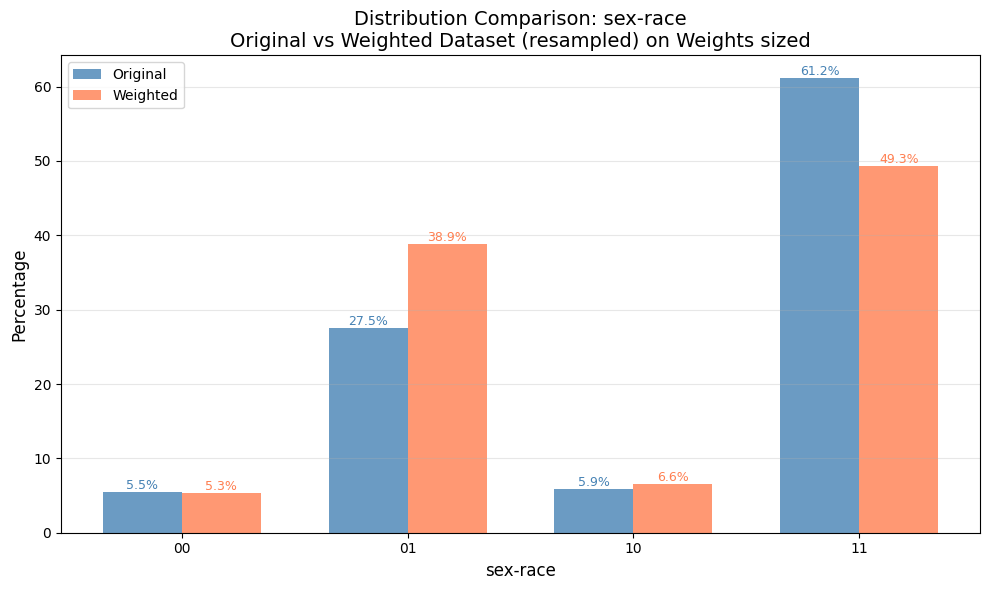

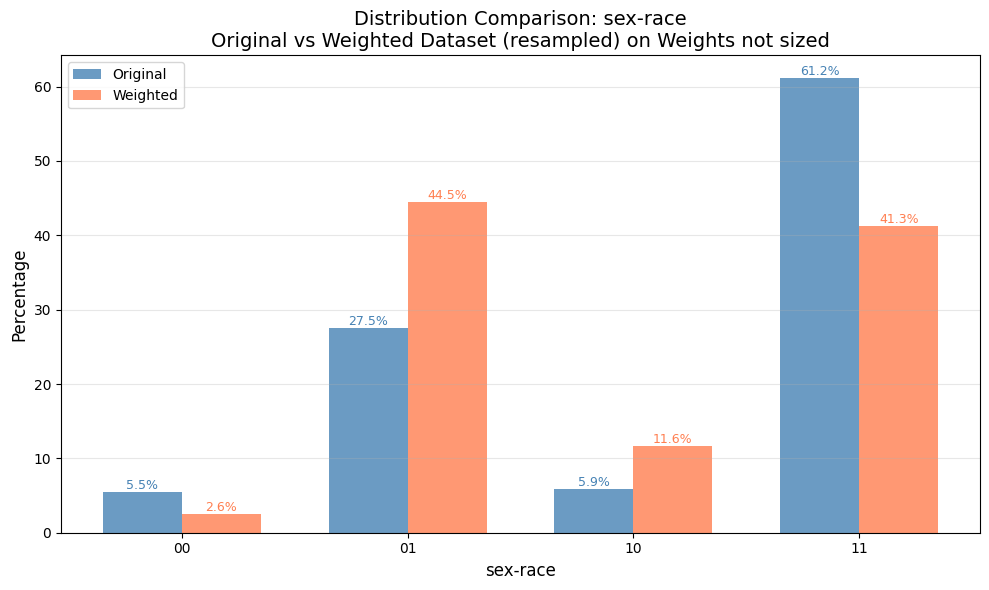

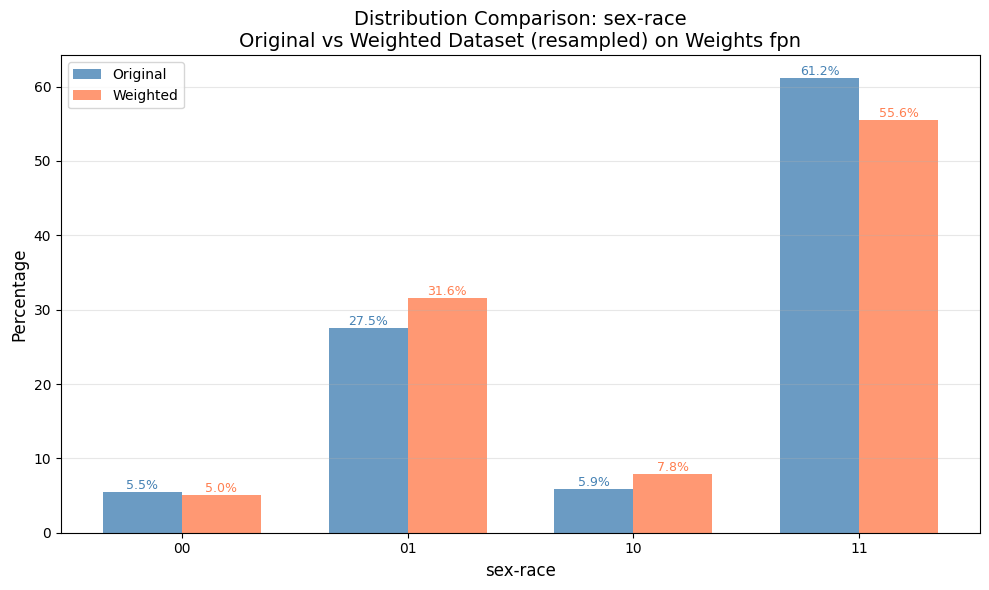

In [80]:
import matplotlib.pyplot as plt

# VISUALIZATION: Distribution Comparison Before/After Reweighting

def plot_distribution_comparison(original_df, resampled_df, column, weight_type):

    # Get distributions - what % of the data belongs to each subgroup (column=sex-race)
    orig_dist = original_df[column].value_counts(normalize=True).sort_index() * 100
    res_dist = resampled_df[column].value_counts(normalize=True).sort_index() * 100
    
    # Align indices
    # all_categories = orig_dist.index.union(res_dist.index).sort_values()
    # labels = ['00', '01', '10', '11']  # Specific order
    labels = original_train_df[column].value_counts().index.sort_values()
    
    # Plot
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, orig_dist.values, width, label='Original', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, res_dist.values, width, label='Weighted', color='coral', alpha=0.8)
    
    # Add value labels on bars
    for bar, val in zip(bars1, orig_dist.values):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, color='steelblue')
    for bar, val in zip(bars2, res_dist.values):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, color='coral')
    
    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel('Percentage', fontsize=12)
    ax.set_title(f'Distribution Comparison: {column}\nOriginal vs Weighted Dataset (resampled) on {weight_type}', fontsize=14)
    
    # x-axis
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45 if len(labels) > 4 else 0, ha='right' if len(labels) > 4 else 'center')
    
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Plot for the sensitive attribute (sex-race)
for key, resampled_train_df in resampled_train_df_dict.items():
    plot_distribution_comparison(original_train_df, resampled_train_df, sensible_attribute, key)

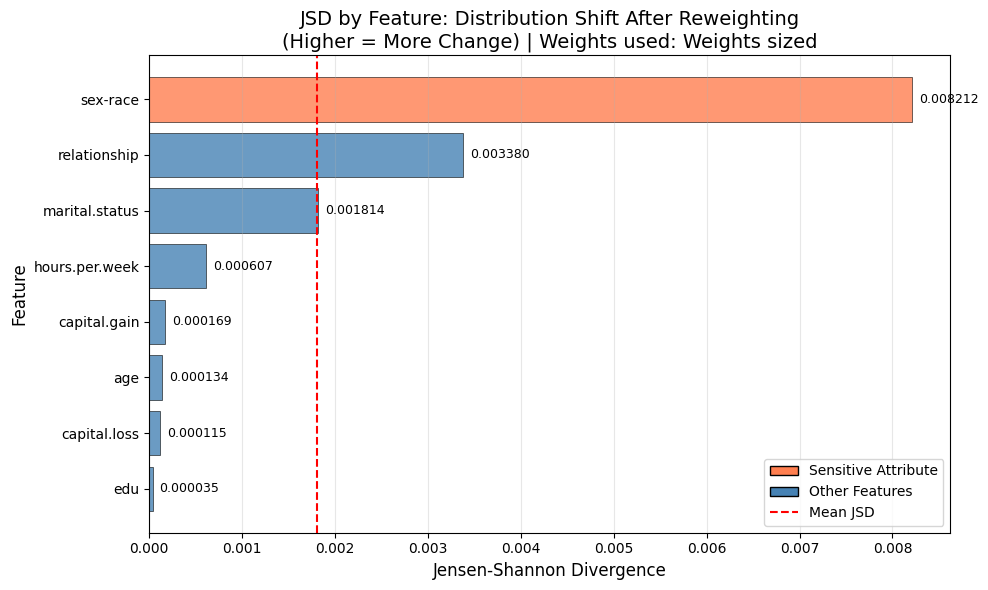

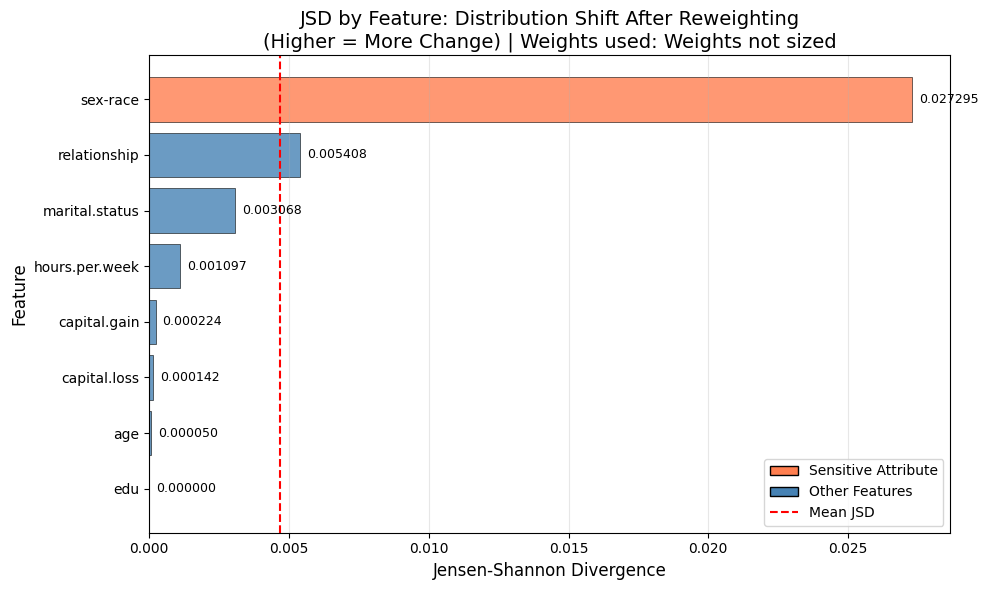

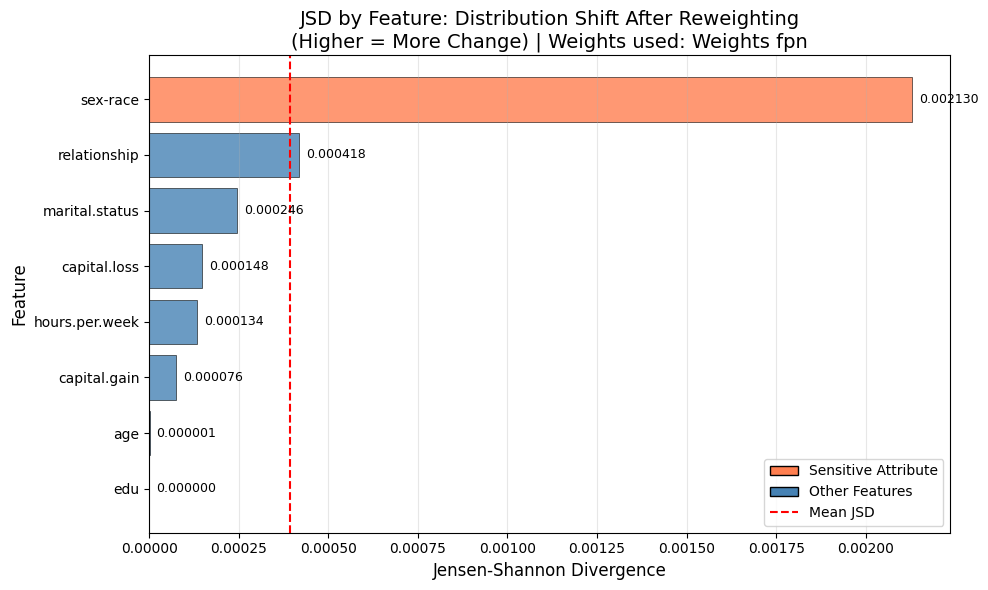

In [85]:
import matplotlib.pyplot as plt

def plot_jsd_bar_chart(resampled_jsd, sensible_attribute, weight_type):
    # Get JSD values and sort by magnitude (highest first)
    jsd_values = resampled_jsd.sort_values(ascending=True)  # ascending for horizontal bar chart

    # Create color palette - highlight sensitive attribute differently
    colors = ['coral' if col == sensible_attribute else 'steelblue' for col in jsd_values.index]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Horizontal bar chart
    bars = ax.barh(jsd_values.index, jsd_values.values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

    # Add value labels on bars
    for bar, val in zip(bars, jsd_values.values):
        ax.annotate(f'{val:.6f}', 
                    xy=(val, bar.get_y() + bar.get_height()/2),
                    xytext=(5, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=9)

    # Labels
    ax.set_xlabel('Jensen-Shannon Divergence', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title(f'JSD by Feature: Distribution Shift After Reweighting\n(Higher = More Change) | Weights used: {weight_type}', fontsize=14)

    # Mean JSD line (interesting addition)
    ax.axvline(x=resampled_jsd.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean JSD ({resampled_jsd.mean():.6f})')

    # Add legend, patch is used because bars don't have labels in this case
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='coral', edgecolor='black', label=f'Sensitive Attribute'),
        Patch(facecolor='steelblue', edgecolor='black', label='Other Features'),
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label=f'Mean JSD')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


for key, resampled_jsd in resampled_jsds.items():
    plot_jsd_bar_chart(resampled_jsd, sensible_attribute, key)

The sensitive attribute 'sex-race' has the highest JSD (0.008589), which is expected since reweighting intentionally shifts its distribution (changes samples) for fairness.

Mean JSD lower than 0.1 means the datasets are still pretty similar. We don't want them to be too dissimilar otherwise we're changing it too much. Objective: make the dataset fair with as low a JSD as possible. The JSD metric can then allow us to check how much we're straying from the original dataset.

---

# Plots

### Comparing performance of the model using weights calculated with different fairness metrics, using three different types of models, and comparing with baseline

FLAT.

### Build dictionaries for the plots

In [ ]:
# TODO: Make it more efficient?
performance_per_metric_model = {}
performance_per_m = {}
model_types = ['GB', 'RF', 'XGB']
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

for model in model_types:
    performance_per_m = {}
    for m in list_of_metrics:
        sensible_attribute = 'sex-race'
        s = sensible_attribute.split('-')
        df=pd.read_csv(dataset_path)
        df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
        df = df.drop(columns=s)

        performance_per_m[m] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric[m], model_type=model)
    performance_per_metric_model[model] = performance_per_m

[[3470  219]
 [ 494  701]]
Precision: 0.7619565217391304, Recall: 0.5866108786610879, Accuracy: 0.854013104013104, F1: 0.6628841607565011
Group 01: before=0.2564102564102564, after=0.14423076923076922, diff=-0.11217948717948717
Group 00: before=0.25, after=0.25, diff=0.0
Group 11: before=0.42387543252595156, after=0.35159010600706714, diff=-0.07228532651888442
Group 10: before=0.21052631578947367, after=0.08571428571428572, diff=-0.12481203007518796
[[3472  217]
 [ 495  700]]
Precision: 0.7633587786259542, Recall: 0.5857740585774058, Accuracy: 0.8542178542178542, F1: 0.6628787878787878
Group 01: before=0.2564102564102564, after=0.14423076923076922, diff=-0.11217948717948717
Group 00: before=0.25, after=0.2222222222222222, diff=-0.02777777777777779
Group 11: before=0.42387543252595156, after=0.34991119005328597, diff=-0.07396424247266559
Group 10: before=0.21052631578947367, after=0.08333333333333333, diff=-0.12719298245614036
[[3472  217]
 [ 495  700]]
Precision: 0.7633587786259542, Re

In [ ]:
performance_per_model_wsized = {}
model_types = ['GB', 'RF', 'XGB']

for model in model_types:
    performance_per_model_wsized[model] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_sized, model_type=model)

[[3424  265]
 [ 463  732]]
Precision: 0.7342026078234705, Recall: 0.6125523012552301, Accuracy: 0.8509418509418509, F1: 0.6678832116788321
Group 01: before=0.2564102564102564, after=0.1792452830188679, diff=-0.07716497339138847
Group 00: before=0.25, after=0.2222222222222222, diff=-0.02777777777777779
Group 11: before=0.42387543252595156, after=0.4149305555555556, diff=-0.008944876970395976
Group 10: before=0.21052631578947367, after=0.13513513513513514, diff=-0.07539118065433853
[[3402  287]
 [ 459  736]]
Precision: 0.7194525904203324, Recall: 0.6158995815899582, Accuracy: 0.8472563472563472, F1: 0.6636609558160504
Group 01: before=0.2564102564102564, after=0.2564102564102564, diff=0.0
Group 00: before=0.25, after=0.25, diff=0.0
Group 11: before=0.42387543252595156, after=0.42439862542955326, diff=0.0005231929036016991
Group 10: before=0.21052631578947367, after=0.20512820512820512, diff=-0.0053981106612685514
[[3434  255]
 [ 463  732]]
[[3402  287]
 [ 459  736]]
Precision: 0.71945259

In [ ]:
performance_per_model_wnotsized = {}
model_types = ['GB', 'RF', 'XGB']

for model in model_types:
    performance_per_model_wnotsized[model] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized, model_type=model)

[[3456  233]
 [ 482  713]]
Precision: 0.7536997885835095, Recall: 0.596652719665272, Accuracy: 0.8536036036036037, F1: 0.6660439047174218
Group 01: before=0.2564102564102564, after=0.14423076923076922, diff=-0.11217948717948717
Group 00: before=0.25, after=0.25, diff=0.0
Group 11: before=0.42387543252595156, after=0.37389770723104054, diff=-0.04997772529491101
Group 10: before=0.21052631578947367, after=0.1111111111111111, diff=-0.09941520467836257
[[3401  288]
 [ 458  737]]
Precision: 0.7190243902439024, Recall: 0.6167364016736402, Accuracy: 0.8472563472563472, F1: 0.663963963963964
Group 01: before=0.2564102564102564, after=0.24786324786324787, diff=-0.008547008547008517
Group 00: before=0.25, after=0.25, diff=0.0
Group 11: before=0.42387543252595156, after=0.4261168384879725, diff=0.002241405962020937
Group 10: before=0.21052631578947367, after=0.23076923076923078, diff=0.02024291497975711
[[3451  238]
 [ 465  730]]
Precision: 0.7541322314049587, Recall: 0.6108786610878661, Accuracy

## Actual Plots

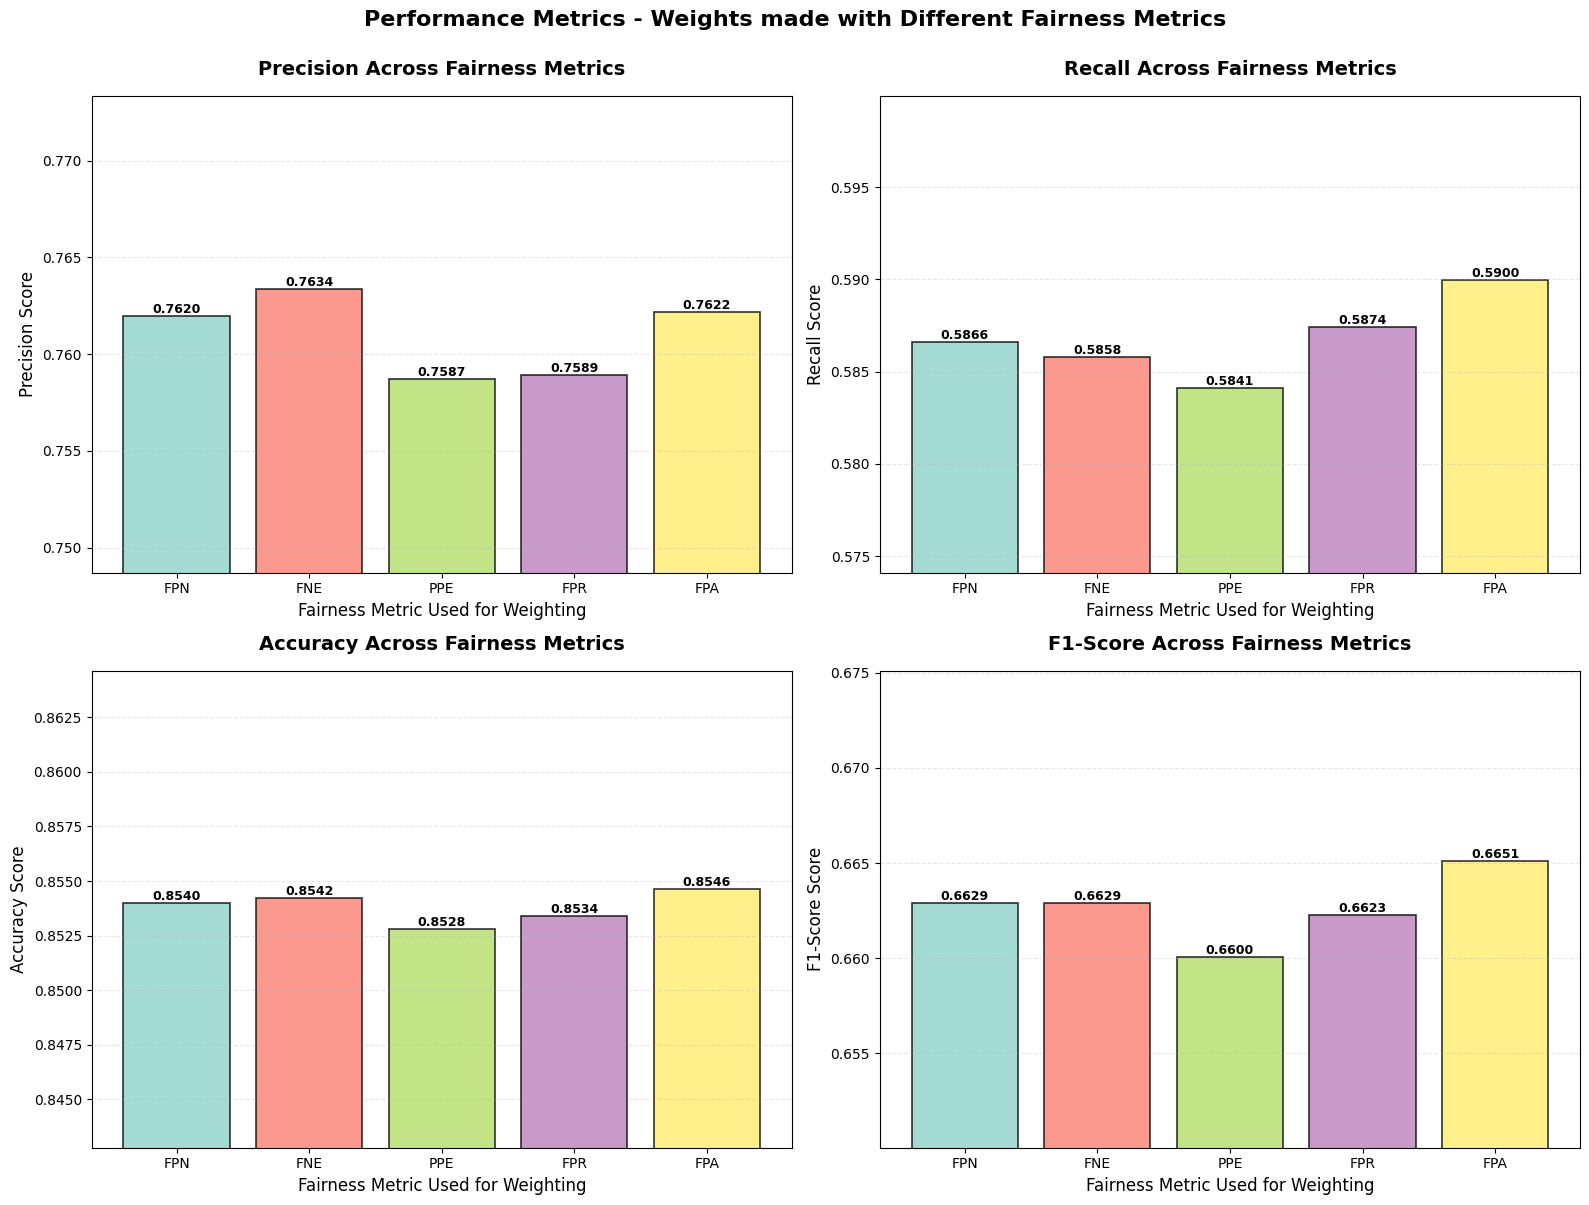

In [ ]:
import matplotlib.pyplot as plt

list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
limit = 5
list_of_metrics_subset = list_of_metrics[:limit]

# Create subplots for each performance metric
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Fixes error

metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']
colors = plt.cm.Set3(np.linspace(0, 1, len(list_of_metrics_subset))) # Using Set3 colormap, create a color for each fairness metric

for idx, metric_name in enumerate(metrics_names):
    ax = axes[idx]
    
    # Extract values for this specific performance metric across all fairness metrics
    values = [performance_per_metric[m][idx] for m in list_of_metrics_subset]
    
    # Create bar chart
    x_pos = np.arange(len(list_of_metrics_subset))
    bars = ax.bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Subplot labels
    ax.set_title(f'{metric_name} Across Fairness Metrics', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fairness Metric Used for Weighting', fontsize=12)
    ax.set_ylabel(f'{metric_name} Score', fontsize=12)
    # Configure x-axis bar labels with as many labels as fairness metrics
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in list_of_metrics_subset])
    
    # Add values on top of bars -----------------------
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add grid and configure y-axis
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_ylim(min(values) - 0.01, max(values) + 0.01)

plt.suptitle('Performance Metrics - Weights made with Different Fairness Metrics', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


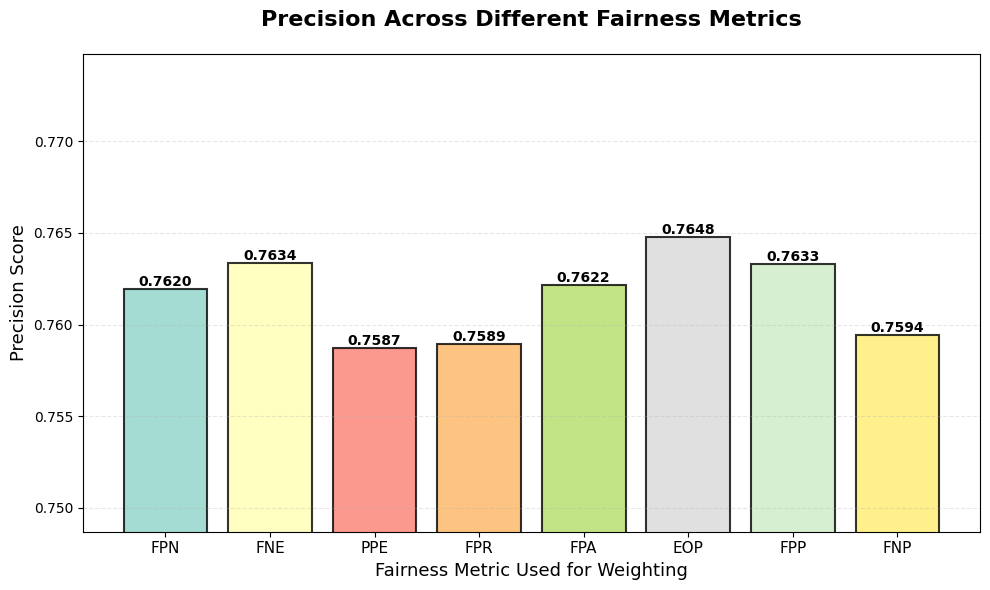

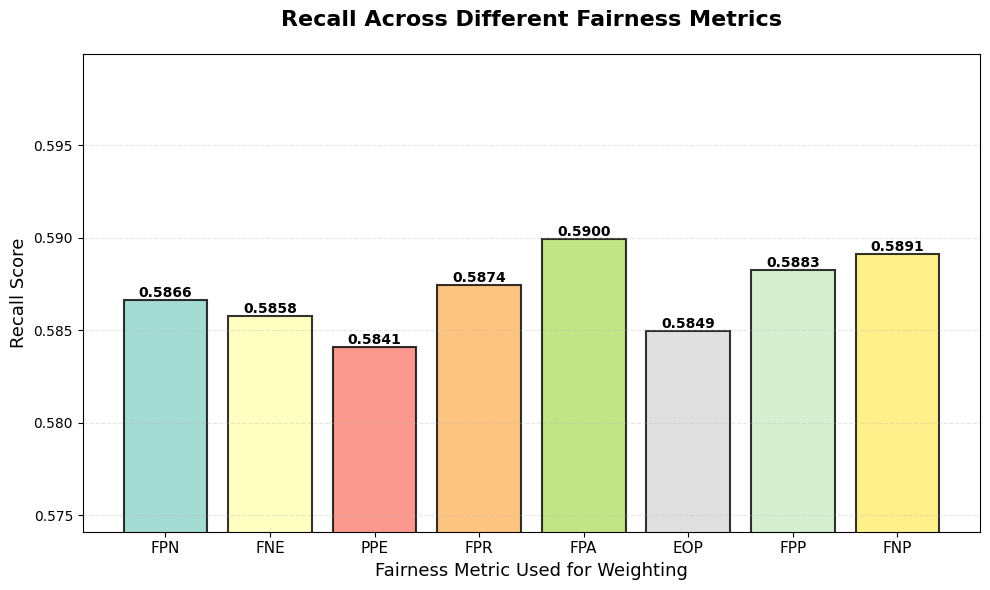

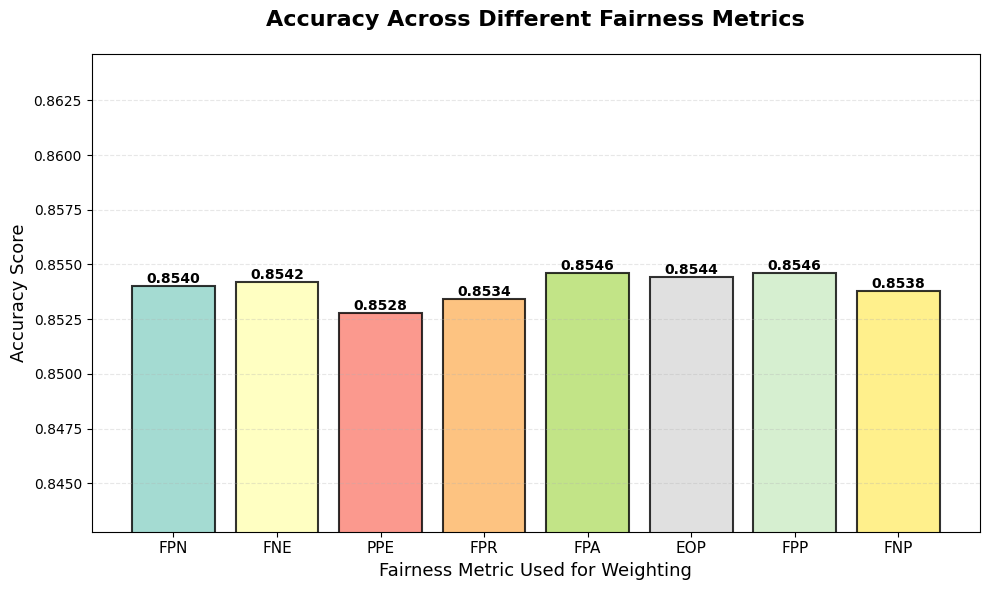

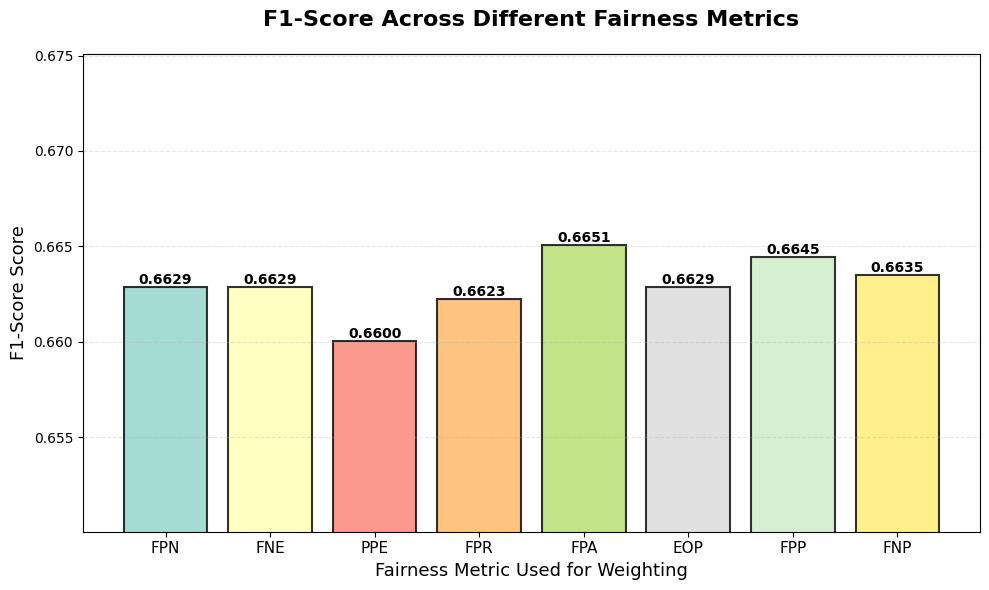

In [ ]:
# Individual plots for each performance metric
import matplotlib.pyplot as plt

list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
limit = len(list_of_metrics)
list_of_metrics_subset = list_of_metrics[:limit]
metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']
colors = plt.cm.Set3(np.linspace(0, 1, len(list_of_metrics_subset)))

# Create individual plot for each performance metric
for idx, metric_name in enumerate(metrics_names):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract values for this specific performance metric across all fairness metrics
    values = [performance_per_metric[m][idx] for m in list_of_metrics_subset]
    
    # Create bar chart
    x_pos = np.arange(len(list_of_metrics_subset))
    bars = ax.bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Subplot labels
    ax.set_title(f'{metric_name} Across Different Fairness Metrics', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Fairness Metric Used for Weighting', fontsize=13)
    ax.set_ylabel(f'{metric_name} Score', fontsize=13)
    # Configure x-axis bar labels with as many labels as fairness metrics
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in list_of_metrics_subset], rotation=0, ha='center', fontsize=11)
    
    # Add values on top of bars
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add grid and configure y-axis
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_ylim(min(values) - 0.01, max(values) + 0.01)
    
    plt.tight_layout()
    plt.show()


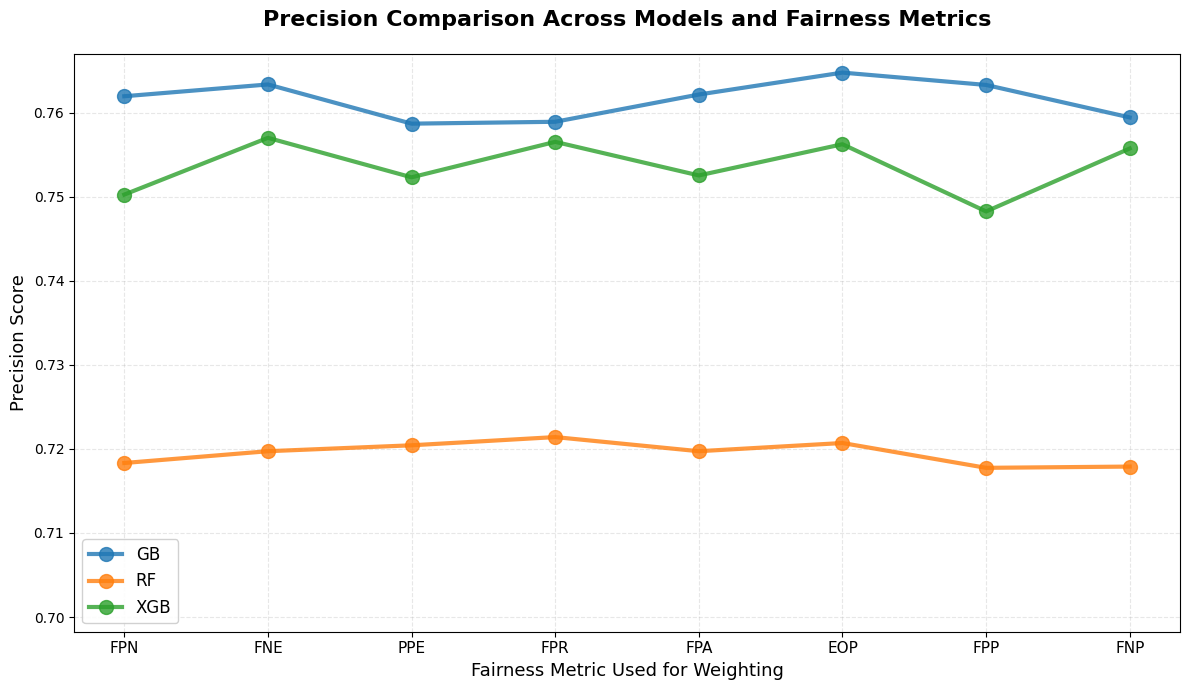

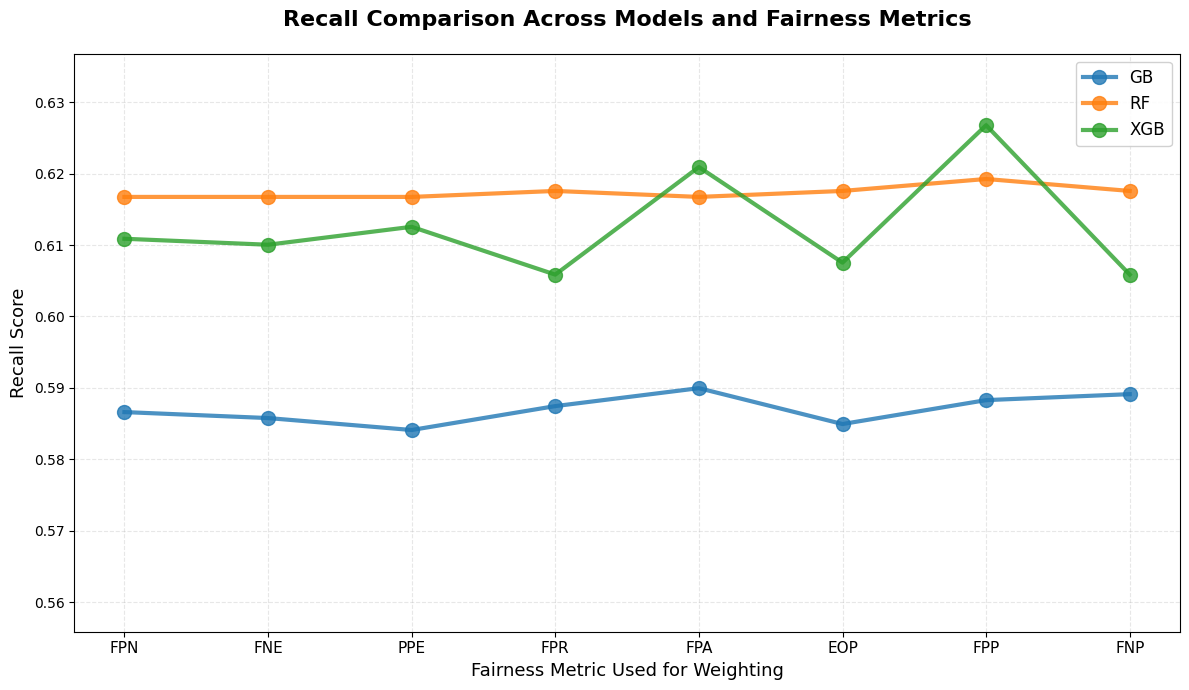

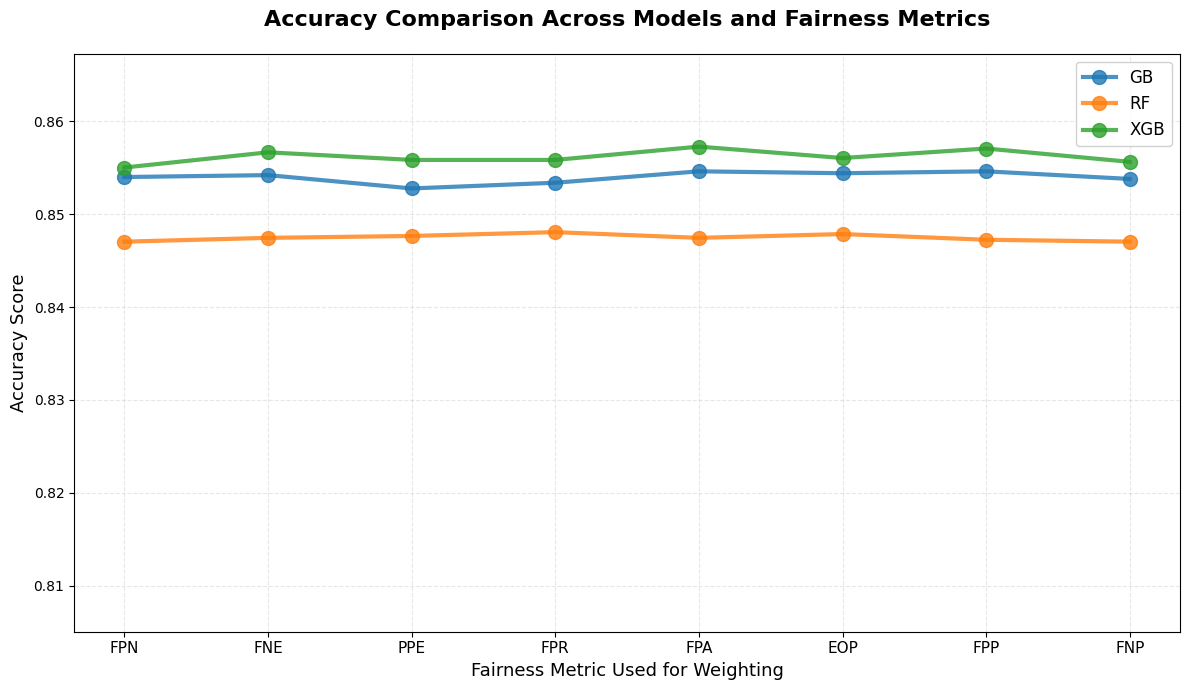

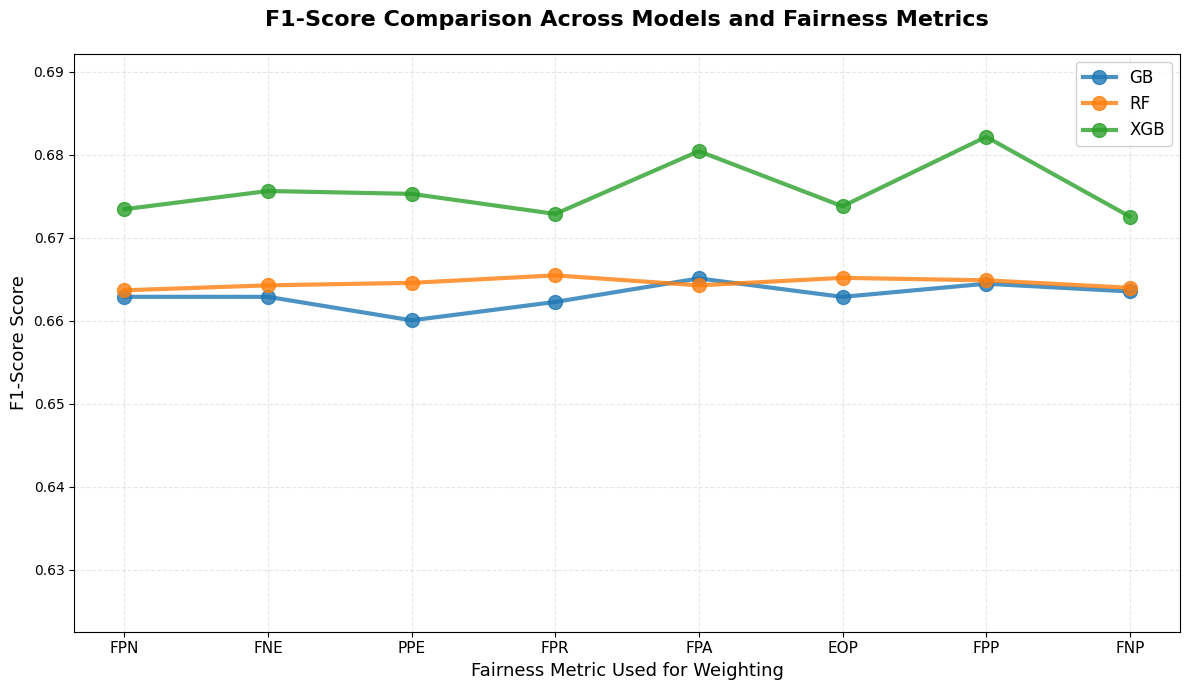

In [ ]:
# Individual line graphs for each performance metric
import matplotlib.pyplot as plt

list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
limit = len(list_of_metrics)
list_of_metrics_subset = list_of_metrics[:limit]
metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']

model_types = ['GB', 'RF', 'XGB']
model_colors = {'GB': '#1f77b4', 'RF': '#ff7f0e', 'XGB': '#2ca02c'}

# Create individual line graph for each performance metric
for idx, metric_name in enumerate(metrics_names):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot line for each model type
    for model in model_types:
        # Extract values for the specific performance metric across all fairness metrics, for a specific model type
        values = [performance_per_metric_model[model][m][idx] for m in list_of_metrics_subset]
        x_pos = np.arange(len(list_of_metrics_subset))

        ax.plot(x_pos, values,
                marker='o',
                color=model_colors[model], 
                label=model, 
                linewidth=3, 
                markersize=10,
                alpha=0.8)
        
    
    # Customize plot
    ax.set_title(f'{metric_name} Comparison Across Models and Fairness Metrics', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Fairness Metric Used for Weighting', fontsize=13)
    ax.set_ylabel(f'{metric_name} Score', fontsize=13)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in list_of_metrics_subset], rotation=0, ha='center', fontsize=11)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, linestyle='--', axis='both')
    ax.set_ylim(min(values) - 0.05, max(values) + 0.01)
    
    # Add legend
    ax.legend(loc='best', fontsize=12, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()


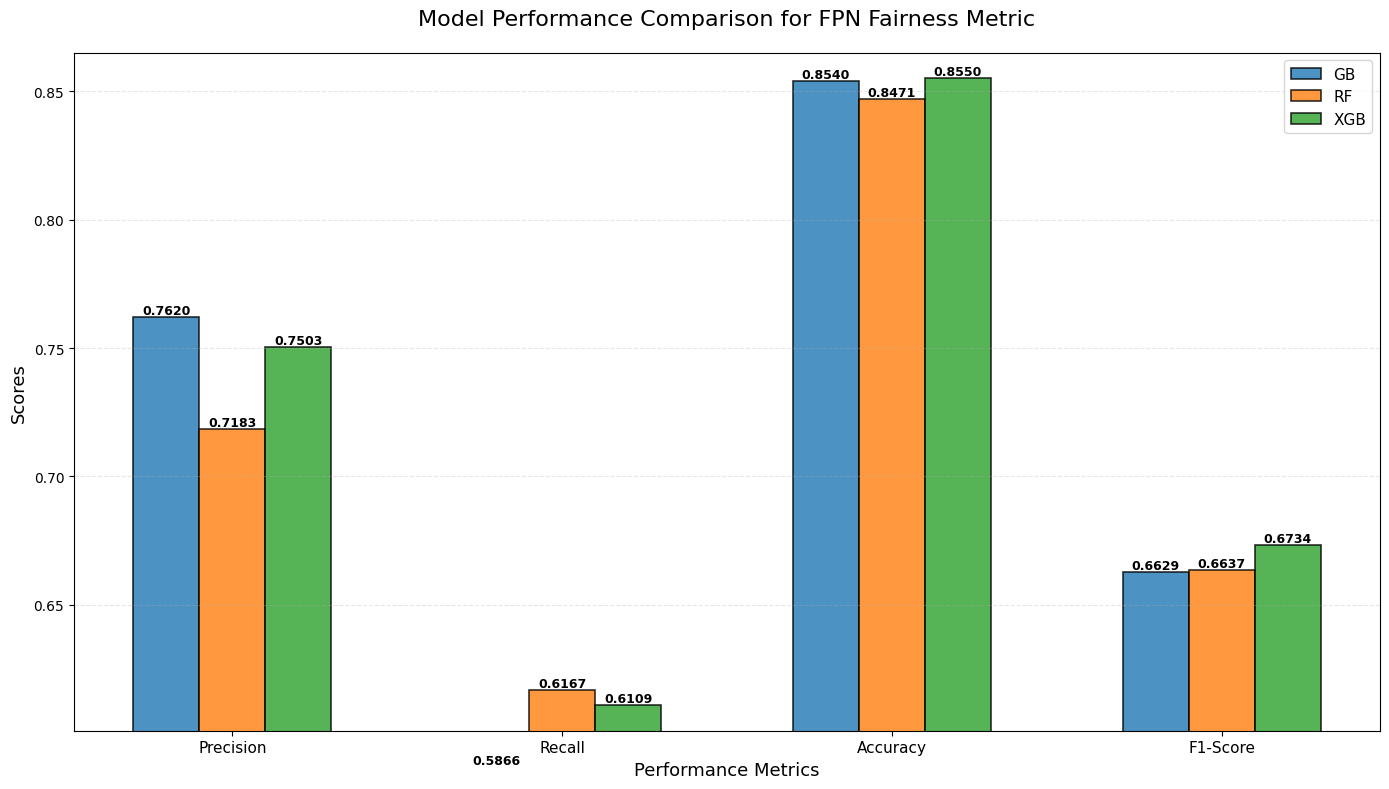

In [ ]:
import matplotlib.pyplot as plt

fairness_metric = 'fpn'
model_types = ['GB', 'RF', 'XGB']
metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']


# Prepare data for plotting
precision_values = [performance_per_metric_model[model][fairness_metric][0] for model in model_types] # list of precision values for each model, where fairness_metric = 'fpn'
recall_values = [performance_per_metric_model[model][fairness_metric][1] for model in model_types]
accuracy_values = [performance_per_metric_model[model][fairness_metric][2] for model in model_types]
f1_values = [performance_per_metric_model[model][fairness_metric][3] for model in model_types]

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Width of each bar and positions
bar_width = 0.2
x = np.arange(len(metrics_names))

# Create bars for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
for idx, model in enumerate(model_types):
    # At each iteration plot bars for each model and all performance metrics
    values = [precision_values[idx], recall_values[idx], accuracy_values[idx], f1_values[idx]]
    positions = x + (idx - 1) * bar_width
    bars = ax.bar(positions, values, bar_width, label=model, color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot labels
ax.set_title(f'Model Performance Comparison for {fairness_metric.upper()} Fairness Metric', 
             fontsize=16, pad=20)
ax.set_xlabel('Performance Metrics', fontsize=13)
ax.set_ylabel('Scores', fontsize=13)

# x-axis bar labels
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_ylim(min(values) - 0.01, max(values) + 0.01)

# Add legend
ax.legend(loc='upper right', fontsize=11, ncol=1)

plt.tight_layout()
plt.show()

## Before/After Comparison - FPN Fairness Metric

Comparing model performance before reweighting (baseline) vs after reweighting with FPN metric

In [ ]:
[performance_per_metric_model['RF'][fairness_metric]]

[(0.7183235867446394,
  0.6167364016736402,
  0.847051597051597,
  0.6636650157586673)]

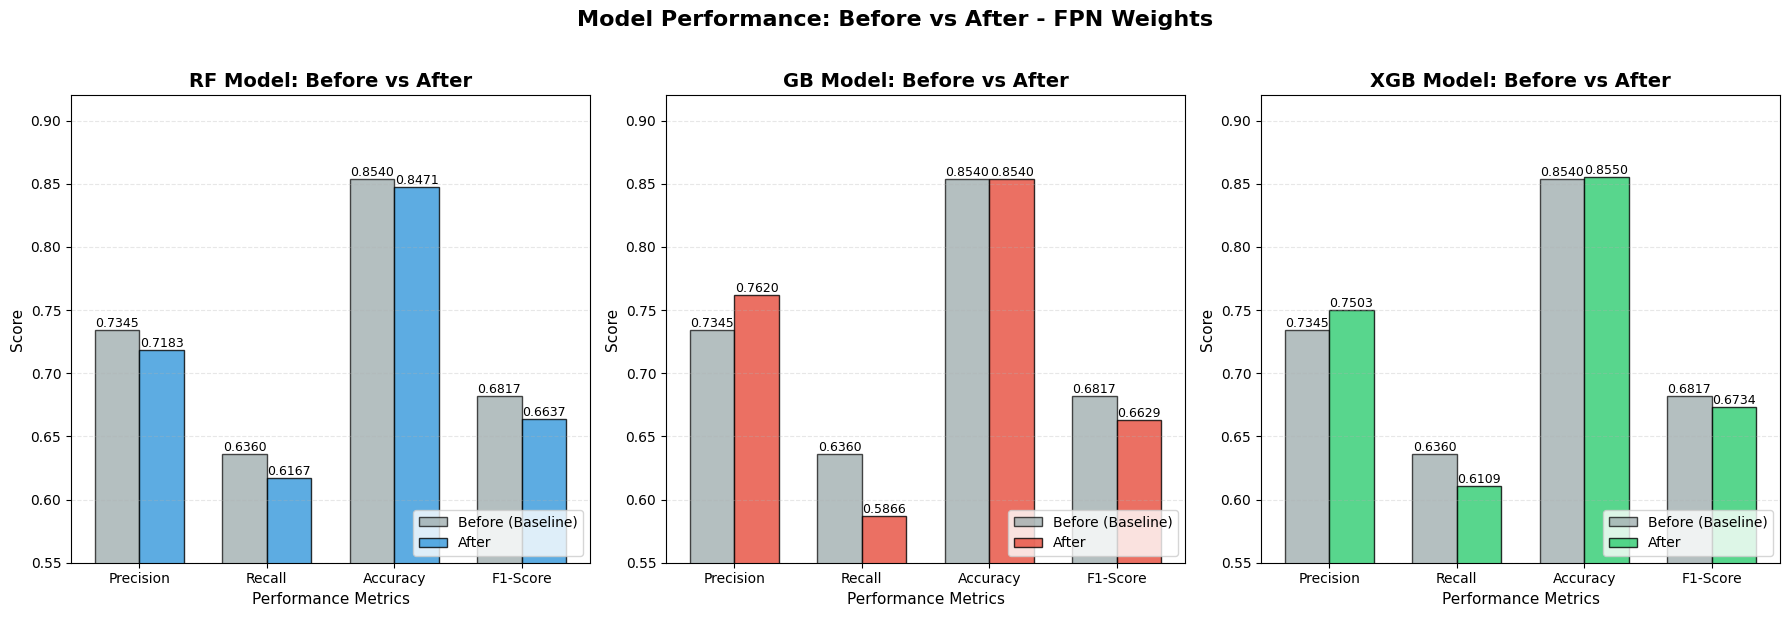

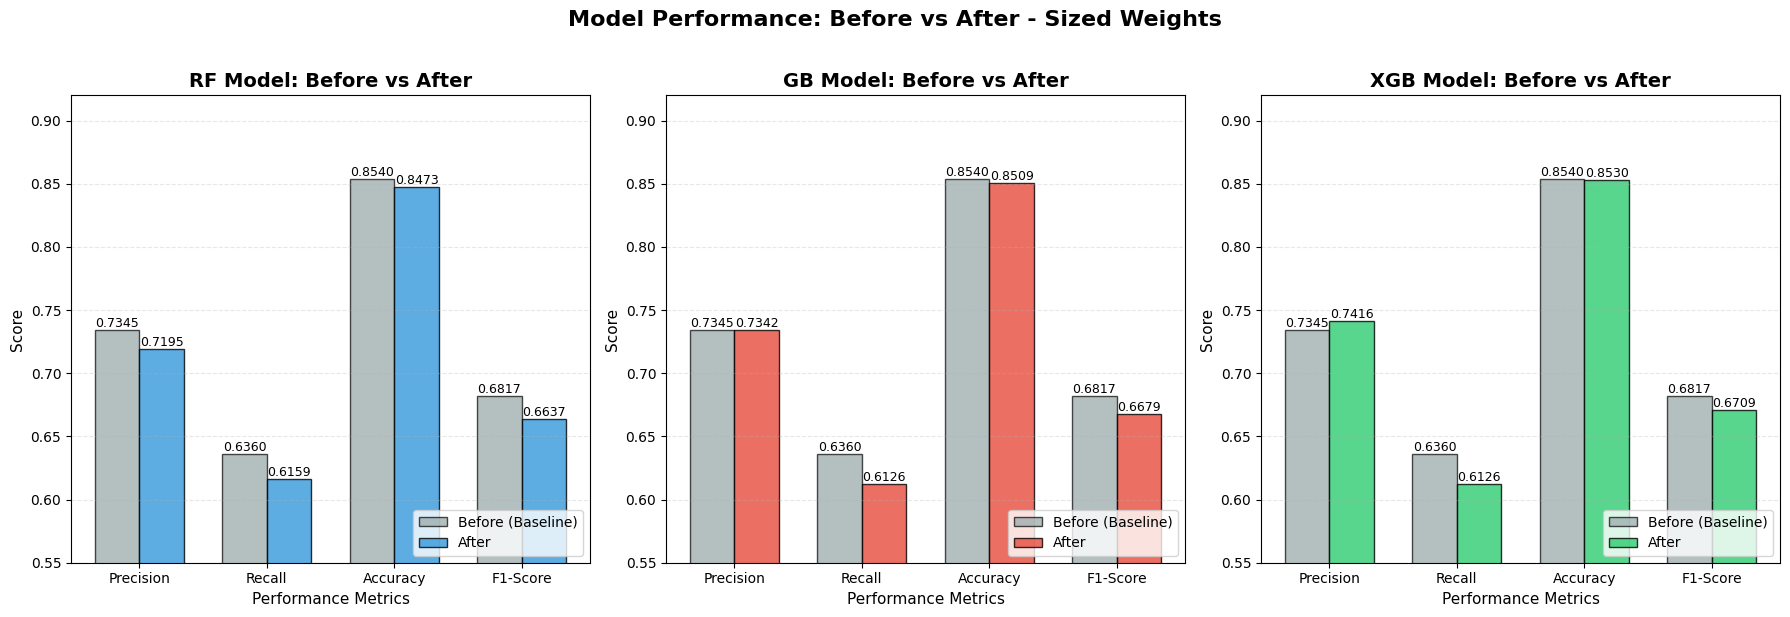

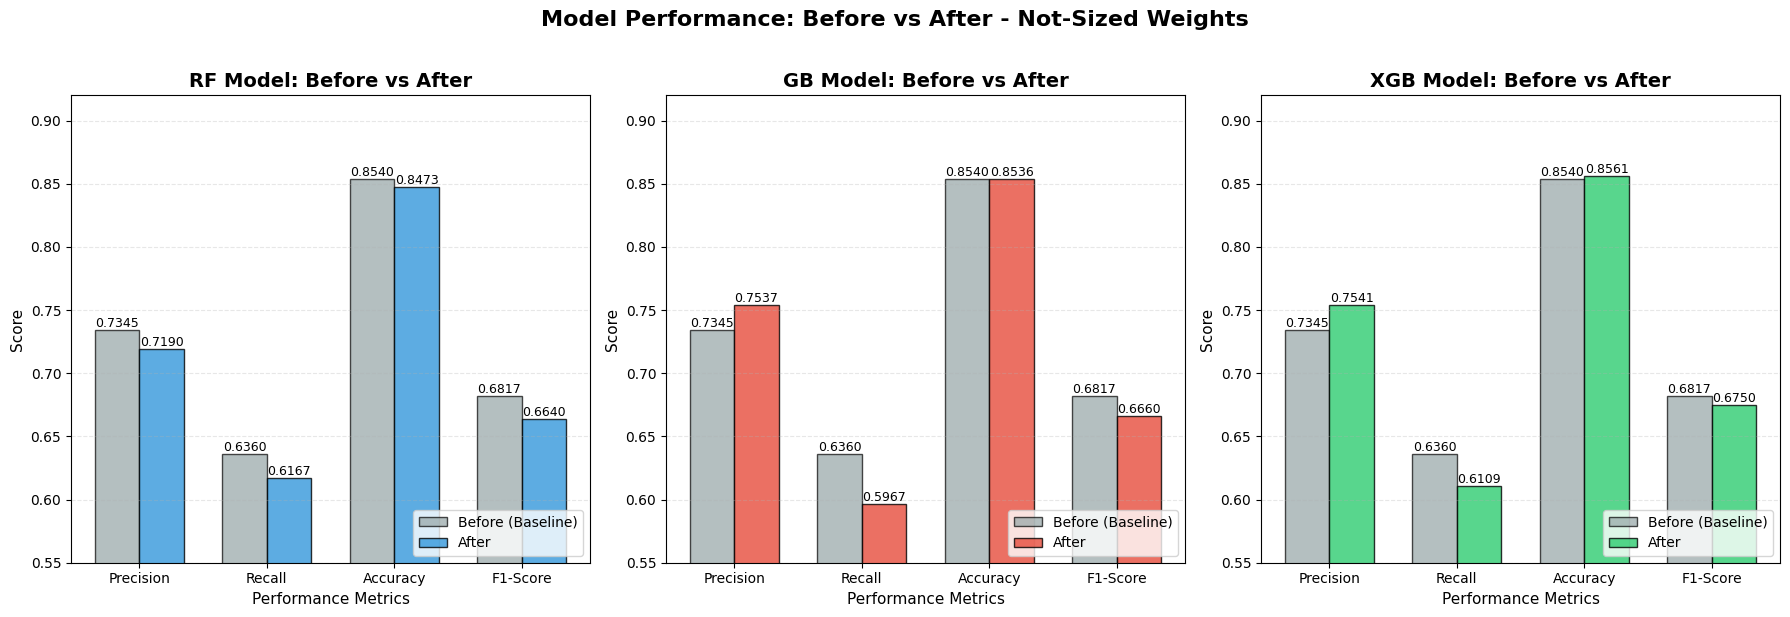

In [ ]:
# Before/After comparison for FPN fairness metric across models
import matplotlib.pyplot as plt
import numpy as np

# Baseline performance (before reweighting)
baseline_performance = {
    'RF': [0.7345, 0.6360, 0.8540, 0.6817],  # Precision, Recall, Accuracy, F1
    'GB': [0.7345, 0.6360, 0.8540, 0.6817],
    'XGB': [0.7345, 0.6360, 0.8540, 0.6817]
}

# Define all three after_performance variants with descriptive names
fairness_metric = 'fpn'
after_performance_variants = {
    'FPN Weights': {
        'RF': list(performance_per_metric_model['RF'][fairness_metric]),
        'GB': list(performance_per_metric_model['GB'][fairness_metric]),
        'XGB': list(performance_per_metric_model['XGB'][fairness_metric])
    },
    'Sized Weights': {
        'RF': list(performance_per_model_wsized['RF']),
        'GB': list(performance_per_model_wsized['GB']),
        'XGB': list(performance_per_model_wsized['XGB'])
    },
    'Not-Sized Weights': {
        'RF': list(performance_per_model_wnotsized['RF']),
        'GB': list(performance_per_model_wnotsized['GB']),
        'XGB': list(performance_per_model_wnotsized['XGB'])
    }
}

metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']
model_types = ['RF', 'GB', 'XGB']
colors_before = '#95a5a6'  # Gray for before
colors_after = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green

# Create 3 separate figures, one for each variant
for variant_name, after_performance in after_performance_variants.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, (ax, model) in enumerate(zip(axes, model_types)):
        x = np.arange(len(metrics_names))
        bar_width = 0.35
        
        # Create grouped bars
        bars_before = ax.bar(x - bar_width/2, baseline_performance[model], bar_width, 
                             label='Before (Baseline)', color=colors_before, alpha=0.7, edgecolor='black')
        bars_after = ax.bar(x + bar_width/2, after_performance[model], bar_width, 
                            label=f'After', color=colors_after[idx], alpha=0.8, edgecolor='black')
        
        # Add value labels
        for bars in [bars_before, bars_after]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}',
                       ha='center', va='bottom', fontsize=9)
        
        # Customize subplot
        ax.set_title(f'{model} Model: Before vs After', fontsize=14, fontweight='bold')
        ax.set_xlabel('Performance Metrics', fontsize=11)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics_names, fontsize=10)
        ax.set_ylim(0.55, 0.92)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.legend(loc='lower right', fontsize=10)

    plt.suptitle(f'Model Performance: Before vs After - {variant_name}', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

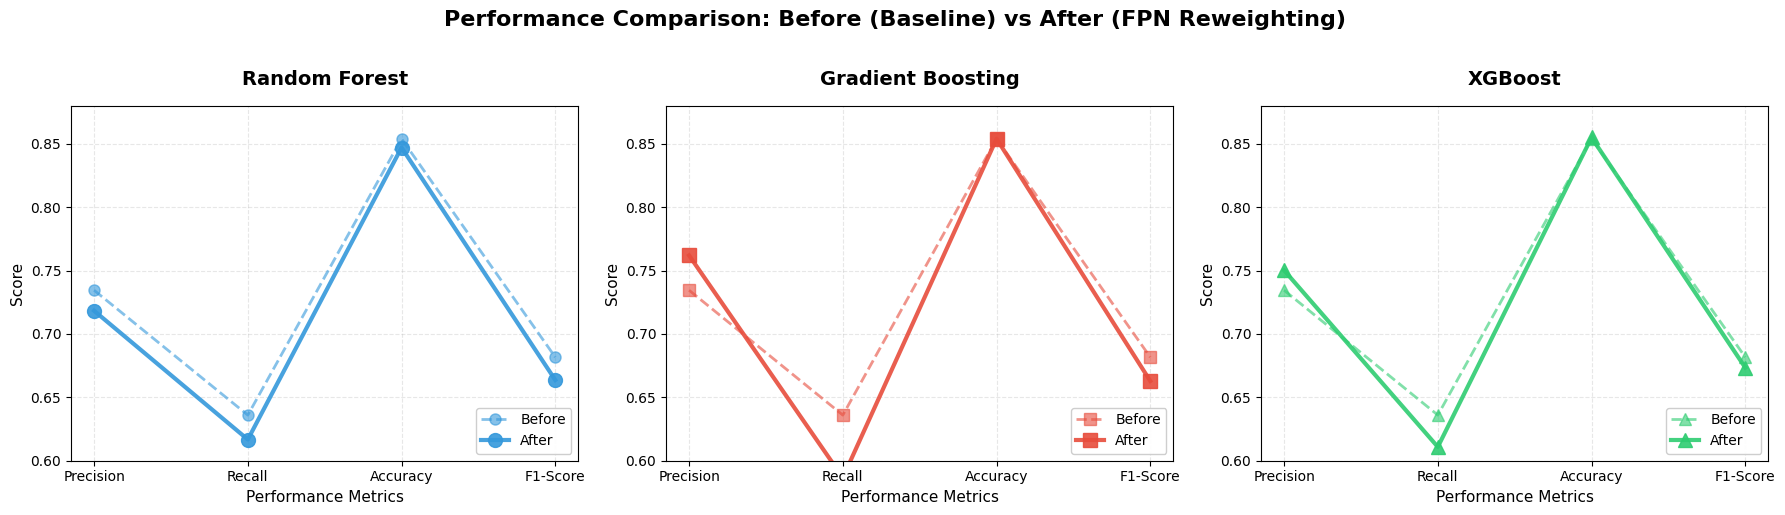

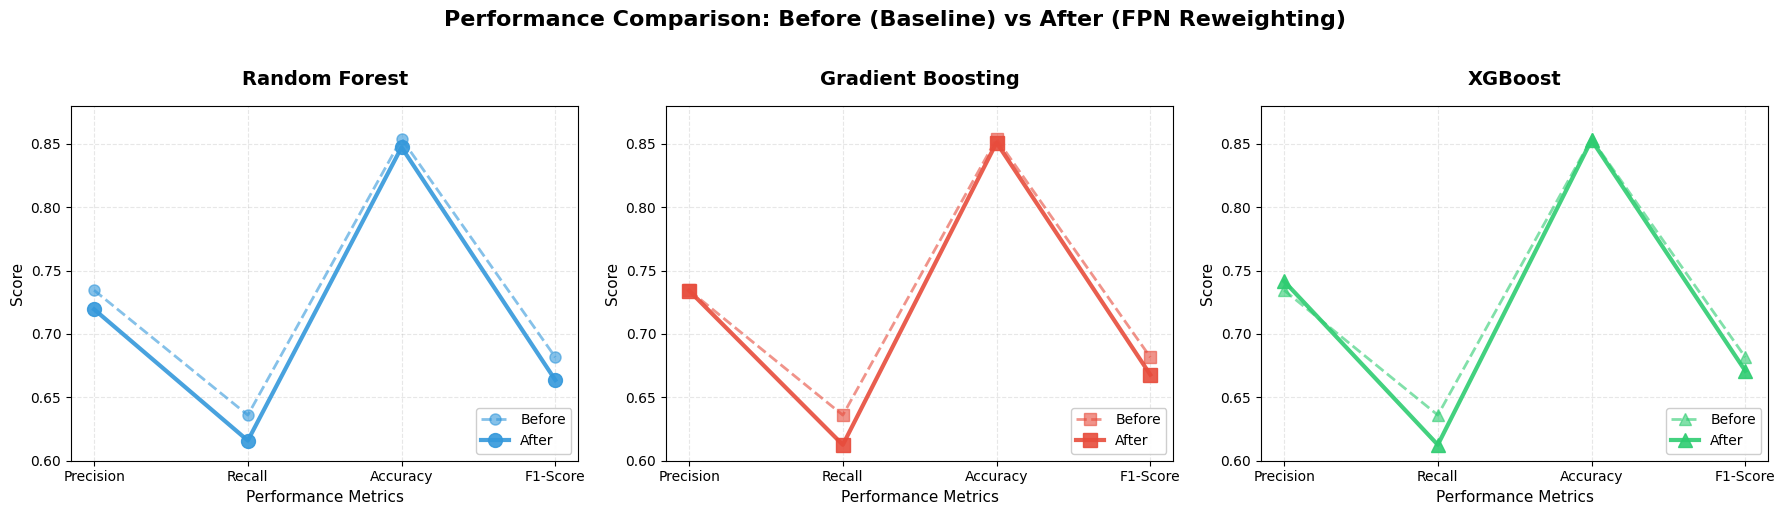

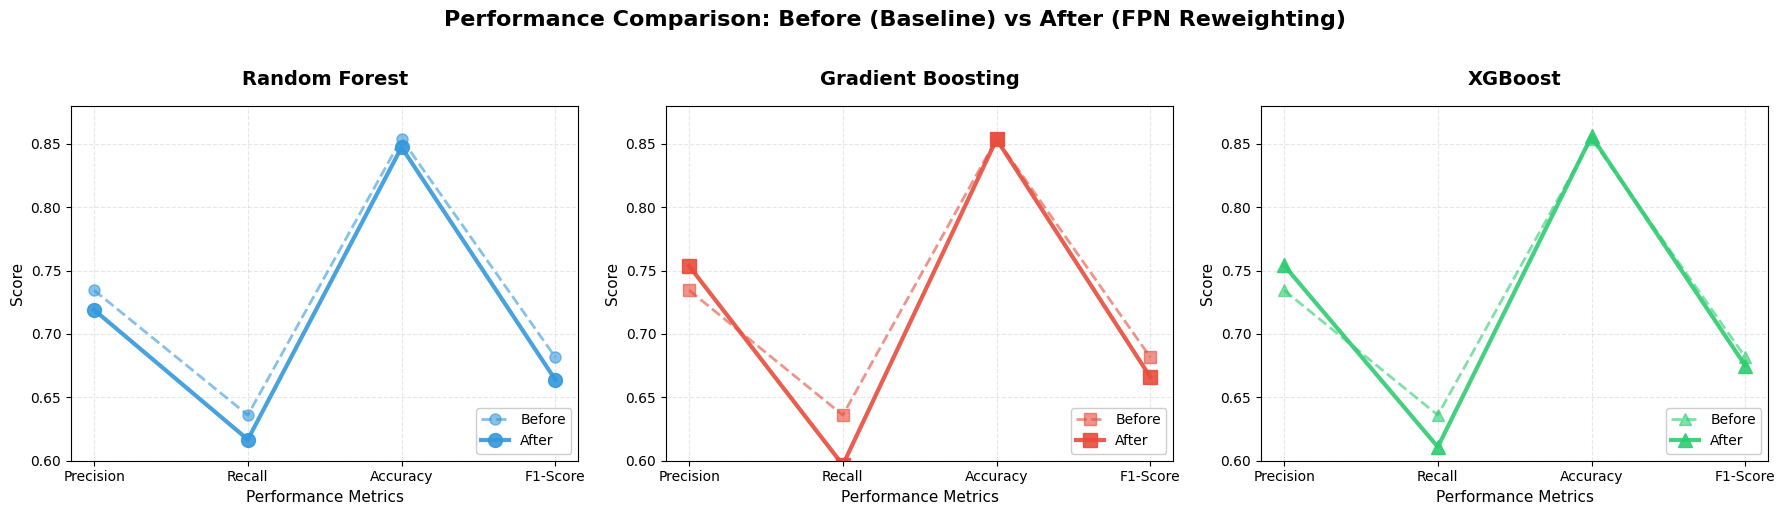

In [ ]:
# Create 3 separate plots, one for each model
import matplotlib.pyplot as plt
import numpy as np

metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']
model_types = ['RF', 'GB', 'XGB']
model_names = {'RF': 'Random Forest', 'GB': 'Gradient Boosting', 'XGB': 'XGBoost'}
x = np.arange(len(metrics_names))

# Colors per model
colors_dict = {'RF': '#3498db', 'GB': '#e74c3c', 'XGB': '#2ecc71'}
markers_dict = {'RF': 'o', 'GB': 's', 'XGB': '^'}

for variant_name, after_performance in after_performance_variants.items():
       # Create figure with 3 subplots
       fig, axes = plt.subplots(1, 3, figsize=(18, 5))
       
       for idx, model in enumerate(model_types):
              ax = axes[idx]

              # Plot baseline (before) - dashed line
              ax.plot(x, baseline_performance[model], 
                     linestyle='--', linewidth=2, 
                     color=colors_dict[model], 
                     marker=markers_dict[model], 
                     markersize=8,
                     alpha=0.6,
                     label='Before')

              # Plot after reweighting - solid line
              ax.plot(x, after_performance[model], 
                     linestyle='-', linewidth=3, 
                     color=colors_dict[model], 
                     marker=markers_dict[model], 
                     markersize=10,
                     alpha=0.9,
                     label='After')

              # Subplot labels
              ax.set_title(f'{model_names[model]}', 
                            fontsize=14, fontweight='bold', pad=15)
              ax.set_xlabel('Performance Metrics', fontsize=11)
              ax.set_ylabel('Score', fontsize=11)
              ax.grid(True, alpha=0.3, linestyle='--', axis='both')
              ax.legend(loc='lower right', fontsize=10, framealpha=0.95)

              # x-axis 
              ax.set_xticks(x)
              ax.set_xticklabels(metrics_names, fontsize=10)

              # y-axis
              ax.set_ylim(0.60, 0.88)
    

       # title
       plt.suptitle('Performance Comparison: Before (Baseline) vs After (FPN Reweighting)', 
              fontsize=16, fontweight='bold', y=1.02)

       plt.tight_layout()
       plt.show()

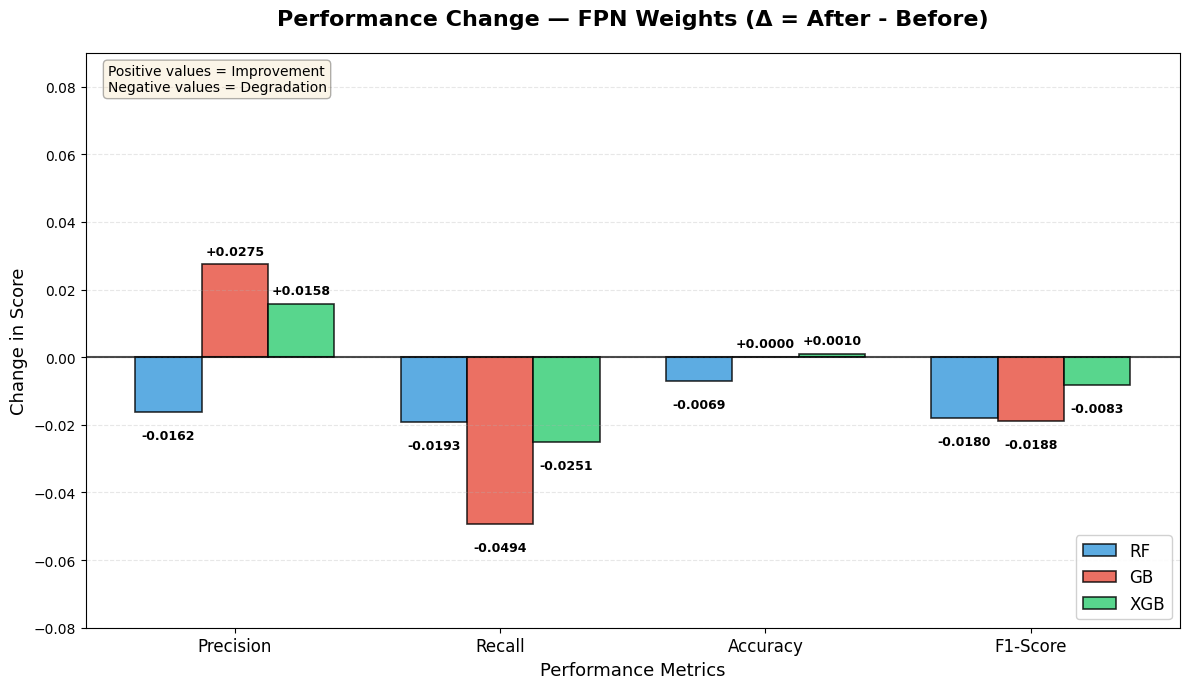

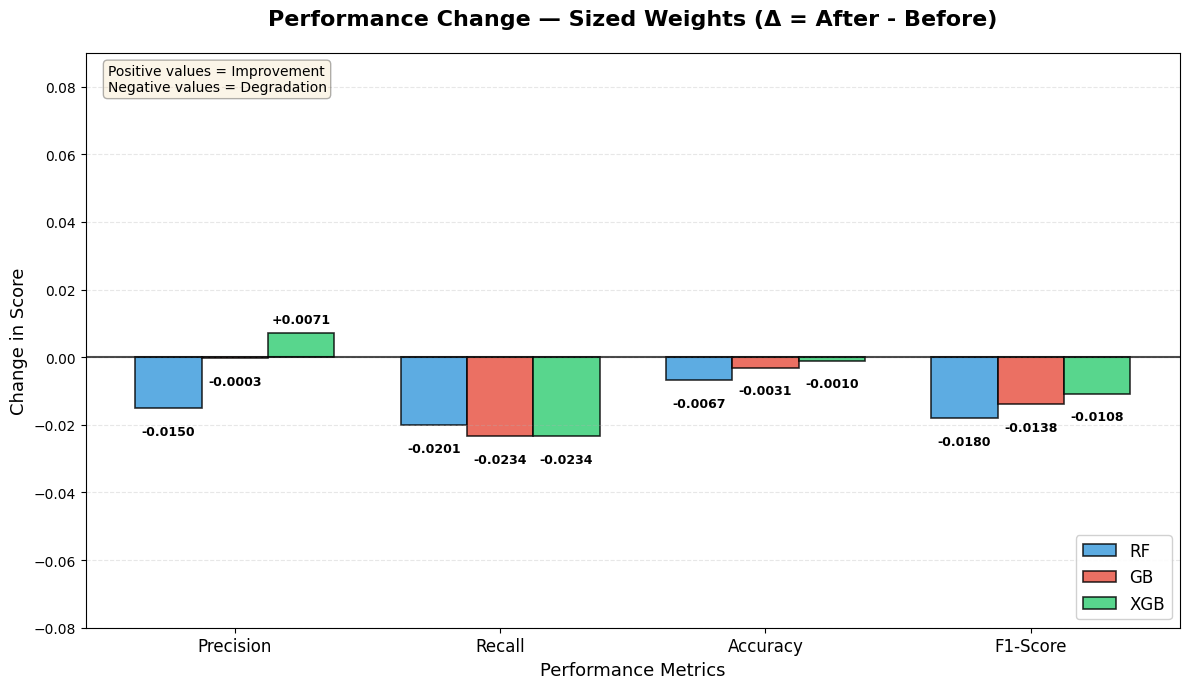

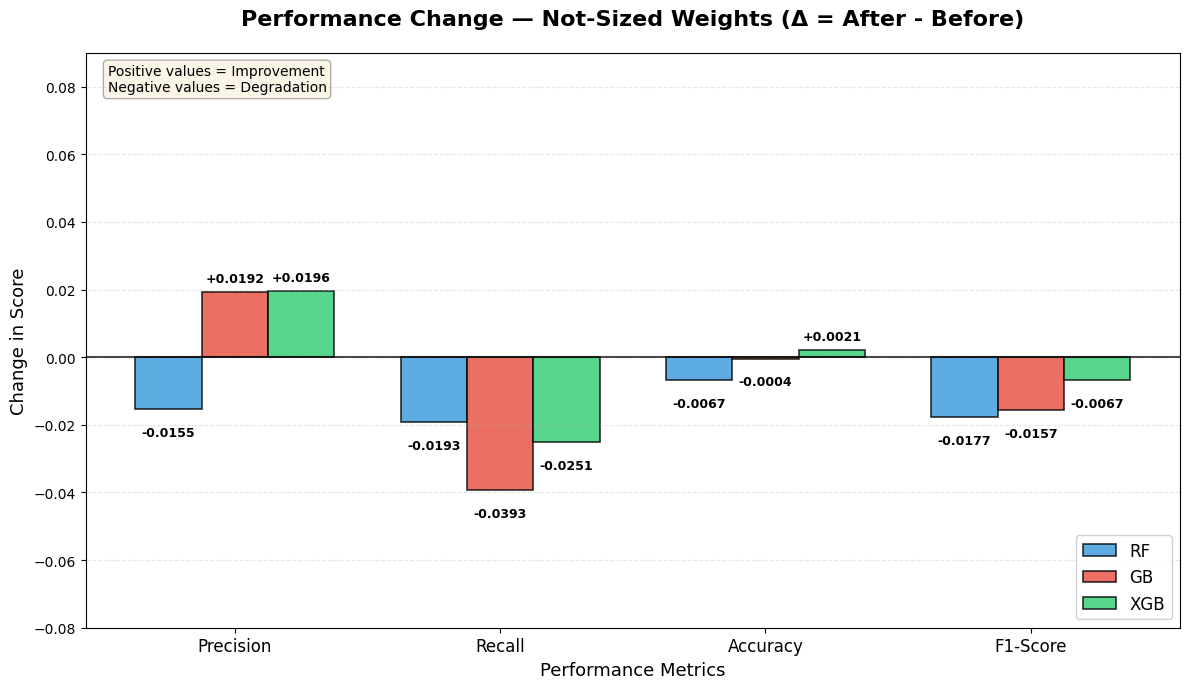

In [ ]:
# Performance change (delta) visualization - showing improvement or degradation
import matplotlib.pyplot as plt
import numpy as np

# Assume same baseline for all models (based on original model performance using RF)
baseline_performance = {
    'RF': [0.7345, 0.6360, 0.8540, 0.6817],  # Precision, Recall, Accuracy, F1
    'GB': [0.7345, 0.6360, 0.8540, 0.6817],
    'XGB': [0.7345, 0.6360, 0.8540, 0.6817]
}

after_performance_variants = {
    'FPN Weights': {
        'RF': list(performance_per_metric_model['RF'][fairness_metric]),
        'GB': list(performance_per_metric_model['GB'][fairness_metric]),
        'XGB': list(performance_per_metric_model['XGB'][fairness_metric])
    },
    'Sized Weights': {
        'RF': list(performance_per_model_wsized['RF']),
        'GB': list(performance_per_model_wsized['GB']),
        'XGB': list(performance_per_model_wsized['XGB'])
    },
    'Not-Sized Weights': {
        'RF': list(performance_per_model_wnotsized['RF']),
        'GB': list(performance_per_model_wnotsized['GB']),
        'XGB': list(performance_per_model_wnotsized['XGB'])
    }
}

metrics_names = ['Precision', 'Recall', 'Accuracy', 'F1-Score']
model_types = ['RF', 'GB', 'XGB']
colors_dict = {'RF': '#3498db', 'GB': '#e74c3c', 'XGB': '#2ecc71'}
bar_width = 0.25

# Calculate the difference (after - before)
for variant_name, after_performance in after_performance_variants.items():
    performance_delta = {}
    for model in model_types:
        performance_delta[model] = [
            after_performance[model][i] - baseline_performance[model][i] 
            for i in range(len(metrics_names))
        ]

    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(metrics_names))

    # Create bars for each model
    for idx, model in enumerate(model_types):
        positions = x + (idx - 1) * bar_width
        deltas = performance_delta[model]
        
        bars = ax.bar(positions, deltas, bar_width, 
                    label=model, 
                    color=colors_dict[model], 
                    alpha=0.8, 
                    edgecolor='black', 
                    linewidth=1.2)
        
        # Add value labels
        for bar, delta in zip(bars, deltas):
            height = bar.get_height()
            label_y = height + 0.002 if height >= 0 else height - 0.005
            va = 'bottom' if height >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2., label_y,
                f'{delta:+.4f}',
                ha='center', va=va, fontsize=9, fontweight='bold')

    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

    # Customize plot
    ax.set_title(f'Performance Change — {variant_name} (Δ = After - Before)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Performance Metrics', fontsize=13)
    ax.set_ylabel('Change in Score', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names, fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
    ax.set_ylim(-0.08, 0.09)

    # Add text annotation explaining positive/negative
    ax.text(0.02, 0.98, 'Positive values = Improvement\nNegative values = Degradation', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    plt.show()

In [ ]:
# Print first n weights that are not equal to 1.0 (i.e. reweighted samples)
def first_n_weights(weights):
    n = 0
    for w in weights:
        if float(w) != 1.0:
            print(w)
            n+=1
        if n == 100:
            break

---

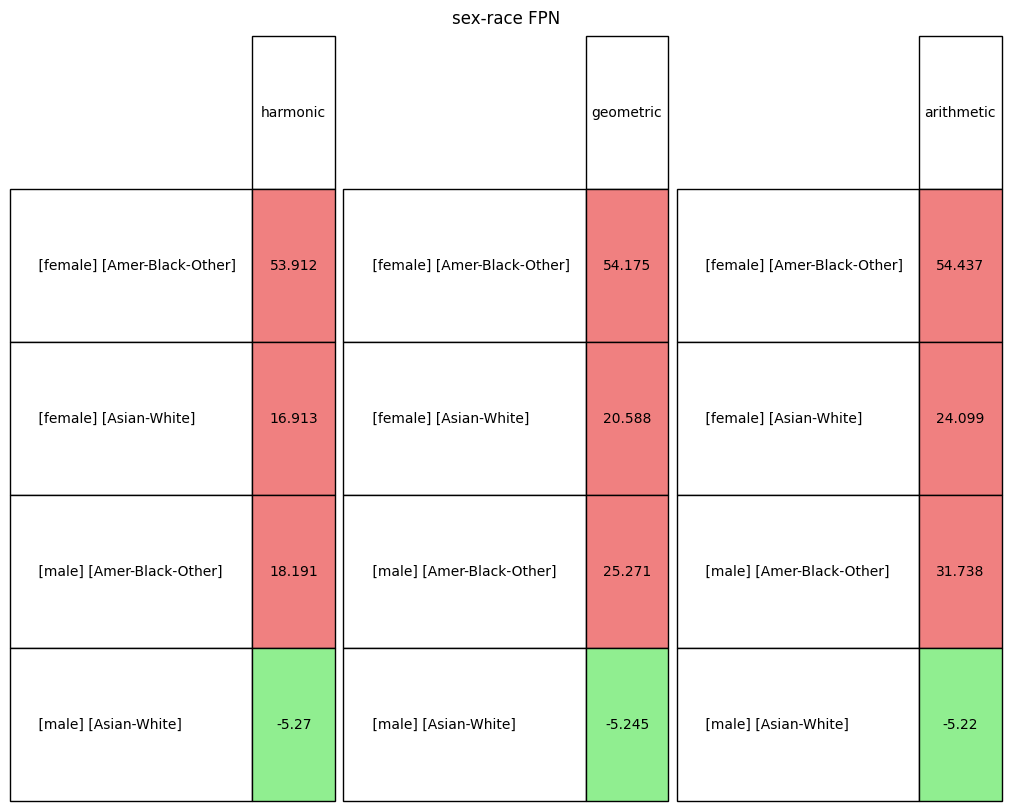

---